# **Portfolio Allocation with a Carbon Objective**

**Course:** Sustainability Aware Asset Management  
**Semester:** Spring 2025–2026  

**Authors:**

- Alessandro Botti  
- Yoann Klingele  
- Charbel Merhi  
- Andrea Perani  

### Output policy

This clean version keeps the calculations and figures, but saves only the main report-ready CSV files. Large audit files such as yearly long weight tables are not exported by default.


This notebook implements the empirical analysis for the *Sustainability Aware Asset Management* project.

The objective is to construct and evaluate portfolio allocation strategies using financial data and carbon emissions information.

## **Reproducibility**

To reproduce the analysis, please follow the steps below:

- Clone the project repository locally.

- Create the Python environment:

```bash
conda env create -f environment.yml
```

- Activate the environment:

```bash
conda activate saam-project
```

- Select the newly created kernel in the notebook.

- Run all cells sequentially from top to bottom.

## **Part I – Standard Portfolio Allocation**

The first part of the project consists of building a portfolio based on the **minimum-variance criterion** and comparing its performance with a **value-weighted benchmark portfolio**.

In [1]:
import pandas as pd
import numpy as np

# Path to the cleaned datasets
path = "../data/cleaned/"

# Load cleaned datasets
ri_m = pd.read_csv(path + "RI_M_cleaned.csv", sep=";", na_values="N/A")
co2 = pd.read_csv(path + "CO2_S1_cleaned.csv", sep=";", na_values="N/A")
static = pd.read_csv(path + "STATIC_cleaned.csv", sep=";", na_values="N/A")

: 

## 1) Data Cleaning

Data cleaning is necessary to construct a meaningful and implementable investment strategy.

The datasets used in this notebook correspond to cleaned versions of the original Datastream files. The cleaning procedure follows the guidelines provided in the project description and was partly conducted manually in Excel.

The main steps applied during the manual cleaning phase are summarized below:

- **Removal of completely missing firms**  
  Some ISIN codes returned no data in the Datastream output (for example due to incorrect share classes or missing carbon information). Firms with no available observations across the datasets were removed so that all tables contain the same set of companies.

- **Treatment of very low prices in the Return Index**  
  In the total return index datasets (monthly and yearly), prices below **0.5** were treated as missing values. Extremely low prices can generate unrealistic or infinite returns when computing percentage changes.

- **Treatment of delistings**  
  When firms are delisted, Datastream typically reports missing values at the end of the sample.  
  To capture the economic effect of delisting, the following rule was applied in the return index datasets:

  - the first missing observation after the last valid price is replaced with **0**
  - all subsequent observations remain *N/A*

  This ensures that the return in the delisting period corresponds to **−100%**, reflecting the loss experienced by investors.

- **Handling missing values within the sample**  
  For annual variables such as **revenues** and **CO₂ emissions**, missing observations between two available years were replaced with the previous available value (forward fill). This assumption reflects delayed or incomplete reporting.

- **Accounting variables left unchanged**  
  Accounting variables such as revenues were **not set to zero when firms delist**. Missing accounting data remain recorded as *N/A*, since a delisting event does not necessarily imply that the firm’s revenues fall to zero.

The datasets directly modified during the cleaning process are mainly the **total return index datasets (RI_M and RI_Y)**, while other datasets remain unchanged except for the forward filling of annual reporting gaps.

After these operations, the datasets contain a consistent set of firms and are suitable for the subsequent portfolio construction steps.

The table below reports the number of firms remaining after these initial cleaning operations.

In [ ]:
print("static shape:", static.shape)
pd.concat([static.head(), static.tail()])

static shape: (618, 4)


,ISIN,NAME,Country,Region
0,AT000000STR1,STRABAG SE,AT,EUR
1,AT00000VIE62,FLUGHAFEN WIEN,AT,EUR
2,AT0000606306,RAIFFEISEN BANK INTL.,AT,EUR
3,AT0000652011,ERSTE GROUP BANK,AT,EUR
4,AT0000720008,TELEKOM AUSTRIA,AT,EUR
613,SE0020050417,BOLIDEN ORD SHS,SE,EUR
614,US0528001094,AUTOLIV,SE,EUR
615,US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,IL,EUR
616,US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,IL,EUR
617,US91822M5022,VEON ADR 1:25,NL,EUR


Some additional data issues are addressed later when constructing the investment set. These include:

- **Stale prices**  
  Some securities may exhibit long periods with unchanged prices due to illiquidity or lack of trading activity.

- **Insufficient return history**  
  Firms with too few available monthly return observations cannot be used to estimate reliable return moments.

- **Carbon data availability**  
  Since the second part of the project introduces carbon constraints, firms without carbon information must be excluded from the investment universe.

- **Investment time horizon**  
  Portfolio allocation starts in **2014**, after using the period **2004–2013** to estimate expected returns and the covariance matrix.

These aspects are addressed in **Section 2.1**, where the investment universe is formally defined.

A more detailed description of the complete cleaning procedure is provided in the report.

Before proceeding with the empirical analysis, we verify that the cleaned datasets contain the same number of firms and reorganize the matrices into a format that is more suitable for portfolio construction.

Note that the CO₂ dataset includes observations for **2025**. These values are retained for carry-forward purposes when computing carbon intensities, but they are not used to construct portfolio allocations for **2026**, since the corresponding monthly return data are not available.

In [ ]:
print("co2 shape:", co2.shape)
co2.head()

co2 shape: (618, 29)


,NAME,ISIN,1999,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,836246,876651,844209,833816,742063,771799,813242,819934,790336,790336
1,FLUGHAFEN WIEN,AT00000VIE62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11796,8455,8958,9648,4745,5663,7567,9027,9847,9847
2,RAIFFEISEN BANK INTL.,AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6027,6270,7696,7455,6392,4827,6049,12403,9375,9375
3,ERSTE GROUP BANK,AT0000652011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22630,27967,27297,29950,24929,21530,20707,18701,16803,16803
4,TELEKOM AUSTRIA,AT0000720008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"14813,3",...,27419,27867,23833,22758,23766,23732,24048,20964,18807,18807


In [ ]:
# Read the year labels and convert them to integers
years = pd.to_numeric(co2.columns[2:], errors="raise").astype(int)

# Create a copy of the dataset and assign year labels to the columns
co2_wide = co2.copy()
co2_wide.columns = ["NAME", "ISIN"] + list(years)

# Use ISIN and NAME as identifiers and sort the columns by year
co2_wide = co2_wide.set_index(["ISIN", "NAME"]).sort_index(axis=1)

# Convert co2 values to numeric format
co2_wide = co2_wide.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

print("co2_wide shape:", co2_wide.shape)
pd.concat([co2_wide.head(), co2_wide.tail()])

co2_wide shape: (618, 27)


,,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,836246.0,876651.00,844209.00,833816.0,742063.0,771799.00,813242.0,819934.0,790336.0,790336.0
AT00000VIE62,FLUGHAFEN WIEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11796.0,8455.00,8958.00,9648.0,4745.0,5663.00,7567.0,9027.0,9847.0,9847.0
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6027.0,6270.00,7696.00,7455.0,6392.0,4827.00,6049.0,12403.0,9375.0,9375.0
AT0000652011,ERSTE GROUP BANK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22630.0,27967.00,27297.00,29950.0,24929.0,21530.00,20707.0,18701.0,16803.0,16803.0
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14813.3,29430.22,16027.64,...,27419.0,27867.00,23833.00,22758.0,23766.0,23732.00,24048.0,20964.0,18807.0,18807.0
SE0020050417,BOLIDEN ORD SHS,NaN,NaN,NaN,NaN,NaN,NaN,703000.0,189936.0,413000.00,473000.00,...,594000.0,605000.00,644000.00,598000.0,544000.0,624794.00,629000.0,627845.0,657646.0,657646.0
US0528001094,AUTOLIV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,102103.61,119092.85,107000.0,98000.0,103000.00,102000.0,95000.0,75000.0,75000.0
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13392.0,13392.00,5170.00,4833.0,3854.0,4238.28,4569.0,4569.0,4569.0,4569.0
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,392268.0,458755.00,372604.00,299146.0,290471.0,282044.00,253306.0,242056.0,243603.0,243603.0


In [ ]:
print("ri_m shape:", ri_m.shape)
ri_m.head()

ri_m shape: (618, 316)


,NAME,ISIN,31/12/99,31/01/00,29/02/00,31/03/00,28/04/00,31/05/00,30/06/00,31/07/00,...,30/04/25,30/05/25,30/06/25,31/07/25,29/08/25,30/09/25,31/10/25,28/11/25,31/12/25,30/01/26
0,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"430,27","430,83","479,46","477,35","465,06","461,5","396,65","452,87","481,49","526,88"
1,FLUGHAFEN WIEN,AT00000VIE62,"147,79","156,25","153,83","158,62","137,27","148,95","159,68","151,08",...,"2339,19","2371,03","2478,96","2417,14","2434,84","2425,66","2409,99","2533,4","2591,68","2587,67"
2,RAIFFEISEN BANK INTL.,AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"113,07","129,28","128,7","123,36","140,73","146,05","158,13","171,78","190,56","215,11"
3,ERSTE GROUP BANK,AT0000652011,"102,94","94,91","97,74","100,5","96,13","97,86","102,06","102,43",...,"1237,75","1536,73","1621,45","1761,42","1818,07","1867,75","1979,03","2087,48","2308,86","2488,84"
4,TELEKOM AUSTRIA,AT0000720008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"343,5","359,25","383,12","360,02","370,54","361,64","360,3","350,11","357,49","360,93"


In [ ]:
# Convert the column labels into datetime format
dates = pd.to_datetime(ri_m.columns[2:], format="%d/%m/%y", errors="coerce")

# Create a copy of the return index dataset and assign the date labels
ri_m_wide = ri_m.copy()
ri_m_wide.columns = ["NAME", "ISIN"] + list(dates)

# Use ISIN and NAME as identifiers and sort the columns by date
ri_m_wide = ri_m_wide.set_index(["ISIN", "NAME"]).sort_index(axis=1)

# Transform the return index values into numeric format
ri_m_wide = ri_m_wide.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

print("ri_m_wide shape:", ri_m_wide.shape)
pd.concat([ri_m_wide.head(), ri_m_wide.tail()])

ri_m_wide shape: (618, 314)


,,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,...,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,430.27,430.83,479.46,477.35,465.06,461.50,396.65,452.87,481.49,526.88
AT00000VIE62,FLUGHAFEN WIEN,147.79,156.25,153.83,158.62,137.27,148.95,159.68,151.08,153.35,161.64,...,2339.19,2371.03,2478.96,2417.14,2434.84,2425.66,2409.99,2533.40,2591.68,2587.67
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,113.07,129.28,128.70,123.36,140.73,146.05,158.13,171.78,190.56,215.11
AT0000652011,ERSTE GROUP BANK,102.94,94.91,97.74,100.50,96.13,97.86,102.06,102.43,106.82,102.31,...,1237.75,1536.73,1621.45,1761.42,1818.07,1867.75,1979.03,2087.48,2308.86,2488.84
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,343.50,359.25,383.12,360.02,370.54,361.64,360.30,350.11,357.49,360.93
SE0020050417,BOLIDEN ORD SHS,16.00,15.72,11.76,11.49,8.90,8.70,7.67,6.87,5.99,5.73,...,37.21,37.84,37.53,37.37,41.71,49.32,54.77,58.06,67.73,85.79
US0528001094,AUTOLIV,85.34,77.68,79.83,87.89,82.58,80.52,70.78,71.70,68.13,57.61,...,678.86,753.90,820.48,817.91,909.71,911.70,862.24,877.52,882.80,901.69
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,159.82,113.50,105.00,102.69,66.01,44.01,58.68,48.64,58.68,47.48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,1649.72,1506.25,1985.68,1718.26,2027.13,2483.16,2555.90,2801.43,2796.27,3376.35,...,3867.12,4183.76,4178.77,3852.16,4582.69,5036.47,5106.29,6704.49,7781.60,8497.18


## 2) Minimum-Variance Portfolio Allocation

The return index values are converted into returns using the simple return definition, $R_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1$.

Returns at date *t* are then collected in the vector $R_t = (R_{1,t}, \ldots, R_{N,t})$, where $N$ denotes the number of firms.

In [ ]:
# Convert return index values into simple returns by computing percentage changes over time
returns_wide = ri_m_wide.pct_change(axis=1, fill_method=None)

print("returns_wide shape:", returns_wide.shape)
pd.concat([returns_wide.head(), returns_wide.tail()])

returns_wide shape: (618, 314)


,,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,...,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.230679,0.001302,0.112875,-0.004401,-0.025746,-0.007655,-0.140520,0.141737,0.063197,0.094270
AT00000VIE62,FLUGHAFEN WIEN,NaN,0.057243,-0.015488,0.031138,-0.134598,0.085088,0.072038,-0.053858,0.015025,0.054059,...,0.040736,0.013612,0.045520,-0.024938,0.007323,-0.003770,-0.006460,0.051208,0.023005,-0.001547
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.041736,0.143363,-0.004486,-0.041492,0.140807,0.037803,0.082711,0.086321,0.109326,0.128831
AT0000652011,ERSTE GROUP BANK,NaN,-0.078007,0.029818,0.028238,-0.043483,0.017996,0.042918,0.003625,0.042859,-0.042221,...,-0.018134,0.241551,0.055130,0.086324,0.032162,0.027326,0.059580,0.054800,0.106051,0.077952
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.135199,0.045852,0.066444,-0.060294,0.029221,-0.024019,-0.003705,-0.028282,0.021079,0.009623
SE0020050417,BOLIDEN ORD SHS,NaN,-0.017500,-0.251908,-0.022959,-0.225413,-0.022472,-0.118391,-0.104302,-0.128093,-0.043406,...,-0.057736,0.016931,-0.008192,-0.004263,0.116136,0.182450,0.110503,0.060069,0.166552,0.266647
US0528001094,AUTOLIV,NaN,-0.089759,0.027678,0.100965,-0.060416,-0.024946,-0.120964,0.012998,-0.049791,-0.154411,...,0.054049,0.110538,0.088314,-0.003132,0.112237,0.002188,-0.054250,0.017721,0.006017,0.021398
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,NaN,-0.289826,-0.074890,-0.022000,-0.357192,-0.333283,0.333333,-0.171097,0.206414,-0.190866,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,NaN,-0.086966,0.318294,-0.134674,0.179757,0.224963,0.029293,0.096064,-0.001842,0.207448,...,0.009110,0.081880,-0.001193,-0.078159,0.189642,0.099020,0.013863,0.312987,0.160655,0.091958


### 2.1) Investment Set

This section defines the investment sets used to construct the out-of-sample portfolios.

The allocation exercise is carried out from the end of **2013** to the end of **2024**.

At the end of each year (**Y**), the investment set is defined as the set of firms that satisfy the following criteria:

- **Sufficient return history**  
  Firms must have enough monthly return observations to estimate expected returns and the covariance matrix. In this notebook, we require at least **3 years of available monthly returns** over the previous **10-year estimation window**.

- **No stale prices**  
  Firms are excluded if the share of zero monthly returns, computed over the available observations in the estimation window, exceeds **50%**.

- **Carbon data availability**  
  Since the second part of the project introduces carbon constraints, only firms with carbon data available at the end of year **Y** are retained.

- **Valid December return index observation**  
  Firms must have a valid return index observation at the end of **December of year Y**, so that they can enter the allocation for year **Y + 1**.

If a firm does not satisfy these criteria at the end of year **Y**, it is excluded from that year’s investment set.

The table below reports the size of the investment set over time, together with the dimensions of the expected return vector and covariance matrix.

Because the covariance matrix is estimated with pairwise correlations, it may not be perfectly positive semi-definite when return histories are incomplete. We therefore apply a small eigenvalue floor after covariance construction. This keeps the risk model mathematically valid and prevents impossible negative variances or zero ex-ante tracking errors caused only by numerical estimation noise.

In [ ]:
# Rebalancing years: portfolios are formed from end-2013 to end-2024
years = range(2013, 2025)

# Main parameters used to define the investment set
tau = 120              # 10 years of monthly returns
min_obs = 36           # at least 3 years of available monthly returns
stale_threshold = 0.50 # maximum 50% of zero returns among available observations

# Keep only firms that are present in the price and carbon panels used later in the analysis
common_firms = ri_m_wide.index.intersection(co2_wide.index)

ri_panel = ri_m_wide.loc[common_firms].copy()
co2_panel = co2_wide.loc[common_firms].copy()

# Pre-compute monthly returns from the RI panel
ret_panel = ri_panel.pct_change(axis=1, fill_method=None)
ret_panel = ret_panel.replace([np.inf, -np.inf], np.nan)

# Store the December date associated with each formation year
year_end_dec = {}

for Y in years:
    dec_dates = [d for d in ri_panel.columns if d.year == Y and d.month == 12]
    if len(dec_dates) == 0:
        raise ValueError(f"No December date found for year {Y}")
    year_end_dec[Y] = max(dec_dates)

# Build a 120-return estimation window ending in December of year Y
# The window is selected by column position rather than calendar subtraction,
# because the RI dates correspond to trading month-end observations
def get_return_window(panel, end_date, n_returns=120):
    end_loc = panel.columns.get_loc(end_date)

    # We need 121 price observations to obtain 120 returns
    start_loc = end_loc - n_returns
    if start_loc < 0:
        raise ValueError(f"Not enough price history before {end_date}")

    price_cols = panel.columns[start_loc:end_loc + 1]
    price_window = panel.loc[:, price_cols]

    return_window = price_window.pct_change(axis=1, fill_method=None)
    return_window = return_window.replace([np.inf, -np.inf], np.nan)

    # Drop the first column, which is missing by construction
    return_window = return_window.iloc[:, 1:]

    return return_window

psd_epsilon = 1e-8  # small eigenvalue floor used to keep covariance matrices valid

# Pairwise covariance matrices can have small negative eigenvalues because each pair
# may be estimated on a different set of months. This helper projects the matrix back
# to a valid covariance matrix so variance and ex-ante tracking error cannot be negative.
def make_psd(matrix, epsilon=psd_epsilon):
    values = matrix.to_numpy(dtype=float)
    values = (values + values.T) / 2.0

    eigvals, eigvecs = np.linalg.eigh(values)
    eigvals = np.maximum(eigvals, epsilon)

    psd_values = eigvecs @ np.diag(eigvals) @ eigvecs.T
    psd_values = (psd_values + psd_values.T) / 2.0

    return pd.DataFrame(psd_values, index=matrix.index, columns=matrix.columns)

# Build covariance using pairwise correlation on the common overlap
# and each asset's own full-window standard deviation
def compute_cov_matrix(est_window):
    # Use sample standard deviation (ddof=1)
    asset_std = est_window.std(axis=1, ddof=1)

    # Pairwise correlation on the common overlap
    corr_matrix = est_window.T.corr()

    # Reconstruct covariance matrix
    sigma = corr_matrix.mul(asset_std, axis=0).mul(asset_std, axis=1).copy()
    sigma = sigma.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # Set the diagonal equal to each asset's own sample variance
    diag_values = asset_std.pow(2)
    for i, asset in enumerate(sigma.index):
        sigma.iat[i, i] = diag_values.loc[asset]

    # The PSD correction is a numerical regularization step, not a carbon assumption.
    # It avoids impossible negative portfolio variances caused by pairwise estimation.
    return make_psd(sigma)

# Define a common investment-set rule for all subsequent sections
def get_investment_set(Y):

    dec_date = year_end_dec[Y]

    # 120 monthly returns ending in December of year Y
    returns_window = get_return_window(ri_panel, dec_date, n_returns=tau)

    # 1) Sufficient return history
    n_available = returns_window.notna().sum(axis=1)
    enough_history = n_available >= min_obs

    # 2) No excessive share of zero returns
    zero_counts = returns_window.eq(0).sum(axis=1)
    zero_share = zero_counts / n_available.replace(0, np.nan)
    not_stale = zero_share <= stale_threshold

    # 3) Carbon data available at the end of year Y
    if Y in co2_panel.columns:
        has_carbon = co2_panel[Y].notna()
    else:
        has_carbon = pd.Series(False, index=co2_panel.index)

    # 4) Valid return index observation in December of year Y
    valid_dec_price = ri_panel[dec_date].notna()

    keep = enough_history & not_stale & has_carbon & valid_dec_price

    return common_firms[keep.fillna(False)]

# Store the yearly investment sets and the corresponding estimation inputs
investment_sets = {}
mu_dict = {}
sigma_dict = {}

for Y in years:

    # Select the firms eligible for year Y
    eligible = get_investment_set(Y)
    dec_date = year_end_dec[Y]

    # Extract the estimation window for the eligible firms
    est_window = get_return_window(ri_panel.loc[eligible], dec_date, n_returns=tau)

    # Store the investment set
    investment_sets[Y] = eligible

    # Estimate expected returns and covariance matrix from the selected window
    mu_dict[Y] = est_window.mean(axis=1)
    sigma_dict[Y] = compute_cov_matrix(est_window)

The table below reports the size of the investment set over time, together with the dimensions of the expected return vector and covariance matrix.

In [ ]:
summary_table = pd.DataFrame({
    "Number of firms": {Y: len(investment_sets[Y]) for Y in years},
    "Expected return vector": {Y: mu_dict[Y].shape for Y in years},
    "Covariance matrix": {Y: sigma_dict[Y].shape for Y in years},
})

summary_table

,Number of firms,Expected return vector,Covariance matrix
2013,477,"(477,)","(477, 477)"
2014,493,"(493,)","(493, 493)"
2015,509,"(509,)","(509, 509)"
2016,515,"(515,)","(515, 515)"
2017,529,"(529,)","(529, 529)"
2018,549,"(549,)","(549, 549)"
2019,574,"(574,)","(574, 574)"
2020,593,"(593,)","(593, 593)"
2021,600,"(600,)","(600, 600)"
2022,592,"(592,)","(592, 592)"


Overall, the size of the investment set increases over most of the sample period, reflecting improved data availability over time, before declining slightly in the final years.

The outputs below report the estimated expected return vectors for **2013** and **2024**, corresponding to the first and last portfolio formation years.

In [ ]:
mu_dict[2013]

ISIN          NAME                                        
AT000000STR1  STRABAG SE                                     -0.000342
AT0000606306  RAIFFEISEN BANK INTL.                           0.009210
AT0000652011  ERSTE GROUP BANK                                0.013121
AT0000720008  TELEKOM AUSTRIA                                 0.003181
AT0000743059  OMV                                             0.017857
                                                                ...   
SE0018012635  WIHLBORGS FASTIGHETER                           0.017928
SE0020050417  BOLIDEN ORD SHS                                 0.026865
US70211M1099  PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23    0.011928
US8816242098  TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1          0.005449
US91822M5022  VEON ADR 1:25                                   0.005762
Length: 477, dtype: float64

In [ ]:
mu_dict[2024]

ISIN          NAME                                  
AT000000STR1  STRABAG SE                                0.013637
AT00000VIE62  FLUGHAFEN WIEN                            0.011278
AT0000606306  RAIFFEISEN BANK INTL.                     0.011045
AT0000652011  ERSTE GROUP BANK                          0.016418
AT0000720008  TELEKOM AUSTRIA                           0.007144
                                                          ...   
SE0018012635  WIHLBORGS FASTIGHETER                     0.012680
SE0020050417  BOLIDEN ORD SHS                           0.013173
US0528001094  AUTOLIV                                   0.008381
US8816242098  TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1    0.002201
US91822M5022  VEON ADR 1:25                             0.009034
Length: 564, dtype: float64

The outputs below report the covariance matrices for the first five firms in the **2013** and **2024** investment sets.

In [ ]:
sigma_dict[2013].iloc[:5, :5]

,ISIN,AT000000STR1,AT0000606306,AT0000652011,AT0000720008,AT0000743059
,NAME,STRABAG SE,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA,OMV
ISIN,NAME,,,,,
AT000000STR1,STRABAG SE,0.020084,0.014374,0.014851,0.006144,0.008677
AT0000606306,RAIFFEISEN BANK INTL.,0.014374,0.020598,0.016882,0.005636,0.008550
AT0000652011,ERSTE GROUP BANK,0.014851,0.016882,0.020279,0.005071,0.007409
AT0000720008,TELEKOM AUSTRIA,0.006144,0.005636,0.005071,0.007344,0.004317
AT0000743059,OMV,0.008677,0.008550,0.007409,0.004317,0.010940


In [ ]:
sigma_dict[2024].iloc[:5, :5]

,ISIN,AT000000STR1,AT00000VIE62,AT0000606306,AT0000652011,AT0000720008
,NAME,STRABAG SE,FLUGHAFEN WIEN,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA
ISIN,NAME,,,,,
AT000000STR1,STRABAG SE,0.004714,0.002675,0.003750,0.003614,0.001431
AT00000VIE62,FLUGHAFEN WIEN,0.002675,0.005991,0.003409,0.003485,0.001471
AT0000606306,RAIFFEISEN BANK INTL.,0.003750,0.003409,0.012837,0.008046,0.003132
AT0000652011,ERSTE GROUP BANK,0.003614,0.003485,0.008046,0.010276,0.002417
AT0000720008,TELEKOM AUSTRIA,0.001431,0.001471,0.003132,0.002417,0.003131


### 2.2) Minimum-Variance Portfolio Allocation

This section implements the long-only minimum-variance portfolio for each portfolio formation year.

At the end of year **Y**, the covariance matrix is estimated using the corresponding **120-month estimation window** defined in **Section 2.1**. The portfolio weights are then obtained by solving a constrained minimum-variance problem under **full investment** and **non-negativity** constraints.

The resulting portfolio is held out of sample during year **Y + 1**. Within the year, weights are updated passively according to asset returns. In addition, the cleaned return index data are used to detect delisting events, so that the first missing month following the last valid observation is treated as a **−100% return**, consistently with the cleaning rules described earlier.

The outputs of this section include the yearly investment set sizes, the portfolio weights, the out-of-sample monthly return series, and the main summary statistics of the minimum-variance strategy.


In [ ]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
from scipy.optimize import minimize

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Section 2.2 uses the objects created in Section 2.1
required_objects = ["years", "investment_sets", "year_end_dec", "ri_panel", "ret_panel", "sigma_dict"]
for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Section 2.1 must be run first. Missing object: {obj}")

# Define input and output paths
data_dir = Path("../data/cleaned")
rf_file = data_dir / "RF.csv"

output_dir = Path("../results/outputs_minvar")
output_dir.mkdir(parents=True, exist_ok=True)

# Set numerical options for the optimization
ridge = 1e-8
solver_maxiter = 2000
ftol = 1e-12
csv_sep = ";"

def solve_minvar(cov_matrix):
    n = cov_matrix.shape[0]

    if n == 0:
        raise ValueError("Covariance matrix is empty.")
    if n == 1:
        return pd.Series([1.0], index=cov_matrix.index)

    Sigma = cov_matrix.to_numpy(dtype=float)
    Sigma = Sigma + ridge * np.eye(n)

    x0 = np.repeat(1 / n, n)

    def objective(w):
        return float(w @ Sigma @ w)

    def objective_grad(w):
        return 2.0 * Sigma @ w

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1.0,
            "jac": lambda w: np.ones_like(w),
        }
    ]
    bounds = [(0.0, 1.0)] * n

    res = minimize(
        objective,
        x0=x0,
        jac=objective_grad,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": solver_maxiter, "ftol": ftol, "disp": False},
    )

    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    w = pd.Series(res.x, index=cov_matrix.index)
    w = w / w.sum()
    return w

def max_drawdown(cumulative_index):
    running_max = cumulative_index.cummax()
    drawdown = cumulative_index / running_max - 1.0
    return drawdown.min()

# Load the risk-free rate series
rf_raw = pd.read_csv(rf_file, sep=csv_sep, na_values=["N/A", "#N/A", "nan", "NaN", ""])

if rf_raw.shape[1] < 2:
    raise ValueError("RF.csv must contain at least one date column and one RF column.")

rf = rf_raw.copy()
rf.columns = ["date_code", "RF"]

# Convert the date codes into month-end dates
rf["date_code"] = rf["date_code"].astype(str).str.strip()
rf["date"] = pd.to_datetime(rf["date_code"], format="%Y%m") + pd.offsets.MonthEnd(0)

# Convert risk-free values to numeric format
rf["RF"] = pd.to_numeric(
    rf["RF"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
) / 100.0

rf_series = rf.set_index("date")["RF"].sort_index()
rf_series = rf_series.loc[rf_series.index <= pd.Timestamp("2025-12-31")]

# Convert to decimals if the series is still expressed in percent units
if len(rf_series.dropna()) > 0 and rf_series.dropna().median() > 1:
    rf_series = rf_series / 100.0

# Build a map of delisting event months from the cleaned monthly RI data
# Delisted firms are typically tagged in the NAME field, and the event month corresponds to the first missing RI observation after the last valid one
delist_pattern = re.compile(r"DEAD|DELIST|SUSP", re.IGNORECASE)
delist_event_month = {}

for asset in ri_panel.index:
    isin, name = asset

    if not delist_pattern.search(name):
        continue

    ri_series = ri_panel.loc[asset]
    valid_dates = ri_series.dropna().index

    if len(valid_dates) == 0:
        continue

    last_valid_date = valid_dates.max()
    future_dates = [d for d in ri_panel.columns if d > last_valid_date]

    if len(future_dates) == 0:
        continue

    first_missing_date = future_dates[0]

    if pd.isna(ri_series[first_missing_date]):
        delist_event_month[asset] = first_missing_date

print(f"Detected {len(delist_event_month)} delisting/suspension event months in RI_M.")

investment_set_rows = []
weights_long_rows = []
oos_rows = []
mv_weights = {}

for Y in years:
    print(f"Formation year {Y} -> OOS year {Y + 1}")

    eligible = investment_sets[Y]
    dec_date = year_end_dec[Y]

    investment_set_rows.append({
        "formation_year": Y,
        "n_eligible": len(eligible)
    })

    if len(eligible) == 0:
        print(f"  Warning: no eligible firms for year {Y}")
        continue

    # Use the covariance matrix already constructed in Section 2.1
    Sigma = sigma_dict[Y].copy()

    # Keep only assets for which the covariance block is fully usable
    valid_assets = Sigma.index[Sigma.notna().all(axis=1)]
    Sigma = Sigma.loc[valid_assets, valid_assets]

    if Sigma.empty:
        print(f"  Warning: covariance matrix is empty for year {Y}")
        continue

    w0 = solve_minvar(Sigma)
    mv_weights[Y] = w0

    for (isin, name), w in w0.items():
        weights_long_rows.append({
            "formation_year": Y,
            "oos_year": Y + 1,
            "ISIN": isin,
            "NAME": name,
            "weight": w
        })

    oos_months = sorted([d for d in ret_panel.columns if d.year == Y + 1])
    if len(oos_months) == 0:
        continue

    current_weights = w0.copy()

    for dt in oos_months:
        r_t = ret_panel.loc[current_weights.index, dt].copy()

        # Apply a -100% return only in the delisting month identified during cleaning
        forced_delist_assets = []
        for asset in r_t.index:
            if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                forced_delist_assets.append(asset)

        if len(forced_delist_assets) > 0:
            r_t.loc[forced_delist_assets] = -1.0

        # All other missing returns remain missing observations
        valid = r_t.notna() & current_weights.notna()
        r_t = r_t[valid]
        w_t = current_weights[valid]

        if len(w_t) == 0:
            oos_rows.append({
                "date": dt,
                "formation_year": Y,
                "oos_year": Y + 1,
                "portfolio_return": np.nan
            })
            continue

        # Re-normalize the observed weights for the current month
        w_t = w_t / w_t.sum()

        rp_t = float((w_t * r_t).sum())

        oos_rows.append({
            "date": dt,
            "formation_year": Y,
            "oos_year": Y + 1,
            "portfolio_return": rp_t
        })

        # Update portfolio weights passively within the year
        denom = 1.0 + rp_t

        if abs(denom) > 1e-12:
            current_weights = w_t * (1.0 + r_t) / denom
            total = current_weights.sum()

            if abs(total) > 1e-12:
                current_weights = current_weights / total
            else:
                current_weights = pd.Series(
                    np.repeat(1 / len(w_t), len(w_t)),
                    index=w_t.index
                )
        else:
            current_weights = pd.Series(
                np.repeat(1 / len(w_t), len(w_t)),
                index=w_t.index
            )

investment_set_sizes = pd.DataFrame(investment_set_rows)
weights_by_year_long = pd.DataFrame(weights_long_rows)

minvar_monthly_returns = pd.DataFrame(oos_rows).sort_values("date").reset_index(drop=True)

if minvar_monthly_returns.empty:
    raise ValueError("No out-of-sample minimum-variance returns were produced.")

minvar_monthly_returns["date"] = pd.to_datetime(minvar_monthly_returns["date"])
minvar_monthly_returns = minvar_monthly_returns[
    (minvar_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (minvar_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

minvar_monthly_returns["cumulative_index"] = (
    1.0 + minvar_monthly_returns["portfolio_return"]
).cumprod()

minvar_cumulative_returns = minvar_monthly_returns[
    ["date", "formation_year", "oos_year", "portfolio_return", "cumulative_index"]
].copy()

full_months = pd.date_range("2014-01-31", "2025-12-31", freq="ME")
template_ready = pd.DataFrame({"date": full_months})
template_ready = template_ready.merge(
    minvar_monthly_returns[["date", "portfolio_return"]],
    on="date",
    how="left"
)
template_ready["date_str"] = template_ready["date"].dt.strftime("%Y-%m")
template_ready = template_ready[["date_str", "portfolio_return"]]

r = minvar_monthly_returns.set_index("date")["portfolio_return"].sort_index().dropna()

# Align the risk-free rate and portfolio returns at the monthly frequency
r_month = r.copy()
r_month.index = r_month.index.to_period("M")

rf_month = rf_series.copy()
rf_month.index = rf_month.index.to_period("M")

rf_aligned = rf_month.reindex(r_month.index)

missing_rf = rf_aligned.isna().sum()
print("Missing RF after monthly alignment:", missing_rf)

if missing_rf > 0:
    raise ValueError("Some monthly RF observations are still missing after month-based alignment.")

excess = r_month - rf_aligned

ann_mean = 12 * r_month.mean()
ann_vol = np.sqrt(12) * r_month.std(ddof=1)

if len(excess.dropna()) >= 2 and excess.std(ddof=1) != 0:
    sharpe = np.sqrt(12) * excess.mean() / excess.std(ddof=1)
else:
    sharpe = np.nan

summary_stats = pd.DataFrame({
    "metric": [
        "Annualized mean return",
        "Annualized volatility",
        "Sharpe ratio",
        "Minimum monthly return",
        "Maximum monthly return",
        "Final cumulative index",
        "Maximum drawdown",
        "Number of monthly observations",
    ],
    "value": [
        ann_mean,
        ann_vol,
        sharpe,
        r.min(),
        r.max(),
        minvar_monthly_returns["cumulative_index"].iloc[-1],
        max_drawdown(minvar_monthly_returns.set_index("date")["cumulative_index"]),
        int(r.notna().sum()),
    ]
})

mv_oos_returns = minvar_monthly_returns.set_index("date")["portfolio_return"].sort_index()

# Save the minimum-variance outputs used by the rest of the notebook
investment_set_sizes.to_csv(output_dir / "investment_set_sizes.csv", index=False)
minvar_monthly_returns.to_csv(output_dir / "minvar_monthly_returns.csv", index=False)
minvar_cumulative_returns.to_csv(output_dir / "minvar_cumulative_returns.csv", index=False)
summary_stats.to_csv(output_dir / "minvar_summary_stats.csv", index=False)

print("Done.")
print(f"Outputs saved in: {output_dir}")

print("\nInvestment set sizes:")
print(investment_set_sizes.to_string(index=False))

print("\nSummary stats:")
print(summary_stats.to_string(index=False))

print("\nReturn series check:")
print("Start:", mv_oos_returns.index.min())
print("End:  ", mv_oos_returns.index.max())
print("Obs:  ", mv_oos_returns.shape[0])


Detected 55 delisting/suspension event months in RI_M.
Formation year 2013 -> OOS year 2014
Formation year 2014 -> OOS year 2015
Formation year 2015 -> OOS year 2016
Formation year 2016 -> OOS year 2017
Formation year 2017 -> OOS year 2018
Formation year 2018 -> OOS year 2019
Formation year 2019 -> OOS year 2020
Formation year 2020 -> OOS year 2021
Formation year 2021 -> OOS year 2022
Formation year 2022 -> OOS year 2023
Formation year 2023 -> OOS year 2024
Formation year 2024 -> OOS year 2025
Missing RF after monthly alignment: 0
Done.
Outputs saved in: ..\results\outputs_minvar

Investment set sizes:
 formation_year  n_eligible
           2013         477
           2014         493
           2015         509
           2016         515
           2017         529
           2018         549
           2019         574
           2020         593
           2021         600
           2022         592
           2023         576
           2024         564

Summary stats:
          

The following figures provide a graphical inspection of the minimum-variance portfolio results.   They illustrate the evolution of the investment universe, portfolio performance, return distribution, and weight concentration over time.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()

# If the notebook is running from /notebooks, move one level up
PROJECT_DIR = BASE_DIR.parent if BASE_DIR.name == "notebooks" else BASE_DIR

# Identify the output directory where the minimum-variance results were saved
if (PROJECT_DIR / "outputs_minvar").exists():
    OUT_DIR = PROJECT_DIR / "outputs_minvar"
elif (PROJECT_DIR / "results" / "outputs_minvar").exists():
    OUT_DIR = PROJECT_DIR / "results" / "outputs_minvar"
else:
    raise FileNotFoundError(
        "Could not find 'outputs_minvar'. Checked both:\n"
        f"- {PROJECT_DIR / 'outputs_minvar'}\n"
        f"- {PROJECT_DIR / 'results' / 'outputs_minvar'}"
    )

# Load output files generated by the minimum-variance allocation
investment = pd.read_csv(OUT_DIR / "investment_set_sizes.csv")
monthly = pd.read_csv(OUT_DIR / "minvar_monthly_returns.csv")
cumulative = pd.read_csv(OUT_DIR / "minvar_cumulative_returns.csv")
# Use the weights already computed in Section 2.2 instead of re-reading a long audit CSV
weights = weights_by_year_long.copy()
summary = pd.read_csv(OUT_DIR / "minvar_summary_stats.csv")

monthly["date"] = pd.to_datetime(monthly["date"])
cumulative["date"] = pd.to_datetime(cumulative["date"])

# Graph 1: Investment set size by formation year
plt.figure(figsize=(10, 6))
plt.plot(investment["formation_year"], investment["n_eligible"], marker="o")
plt.title("Eligible Universe Size by Formation Year")
plt.xlabel("Formation Year")
plt.ylabel("Number of Eligible Firms")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_investment_set_sizes.png", dpi=300)
plt.close()

# Graph 2: Cumulative performance of the minimum-variance portfolio
plt.figure(figsize=(12, 6))
plt.plot(cumulative["date"], cumulative["cumulative_index"])
plt.title("Minimum-Variance Portfolio Cumulative Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Index")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_cumulative_performance.png", dpi=300)
plt.close()

# Graph 3: Monthly portfolio returns
plt.figure(figsize=(12, 6))
plt.bar(monthly["date"], monthly["portfolio_return"])
plt.title("Minimum-Variance Portfolio Monthly Returns")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_monthly_returns.png", dpi=300)
plt.close()

# Graph 4: Annual portfolio returns
monthly["year"] = monthly["date"].dt.year
annual_returns = (
    monthly.groupby("year")["portfolio_return"]
    .apply(lambda x: (1 + x).prod() - 1)
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.bar(annual_returns["year"].astype(str), annual_returns["portfolio_return"])
plt.title("Minimum-Variance Portfolio Annual Returns")
plt.xlabel("Year")
plt.ylabel("Annual Return")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_annual_returns.png", dpi=300)
plt.close()

# Graph 5: Top 10 portfolio weights in the latest formation year
latest_year = int(weights["formation_year"].max())
top_weights = (
    weights[weights["formation_year"] == latest_year]
    .sort_values("weight", ascending=False)
    .head(10)
    .sort_values("weight", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(top_weights["NAME"], top_weights["weight"])
plt.title(f"Top 10 Portfolio Weights - Formation Year {latest_year}")
plt.xlabel("Weight")
plt.ylabel("Company")
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_top10_weights_latest_year.png", dpi=300)
plt.close()

# Graph 6: Rolling 12-month portfolio return
rolling_12m = monthly[["date", "portfolio_return"]].copy()
rolling_12m["rolling_12m_return"] = (
    (1 + rolling_12m["portfolio_return"])
    .rolling(12)
    .apply(lambda x: x.prod() - 1, raw=True)
)

plt.figure(figsize=(12, 6))
plt.plot(rolling_12m["date"], rolling_12m["rolling_12m_return"])
plt.title("Rolling 12-Month Return")
plt.xlabel("Date")
plt.ylabel("Rolling 12-Month Return")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_rolling_12m_return.png", dpi=300)
plt.close()

print("Graphs created successfully.")
print()
print("Files created:")
print("- graph_investment_set_sizes.png")
print("- graph_cumulative_performance.png")
print("- graph_monthly_returns.png")
print("- graph_annual_returns.png")
print("- graph_top10_weights_latest_year.png")
print("- graph_rolling_12m_return.png")


Graphs created successfully.

Files created:
- graph_investment_set_sizes.png
- graph_cumulative_performance.png
- graph_monthly_returns.png
- graph_annual_returns.png
- graph_top10_weights_latest_year.png
- graph_rolling_12m_return.png


### 2.3 Comparison with the value-weighted portfolio

This section compares the out-of-sample minimum-variance portfolio to a value-weighted benchmark.

For each month, the value-weighted portfolio uses the market capitalizations observed at the end of the previous month to compute portfolio weights. The benchmark is constructed on the same yearly investment set defined in **Section 2.1**, ensuring that the comparison with the minimum-variance portfolio remains consistent.

The two strategies are evaluated over the **2014–2025** out-of-sample period using the following performance metrics:

- **Annualized mean return**  
  The cumulative growth of a $1 investment over the out-of-sample period, computed by compounding monthly returns.
  
- **Annualized mean return**  
  The average monthly portfolio return scaled to an annual frequency.

- **Annualized volatility**  
  The standard deviation of monthly returns, annualized to measure the overall risk of the strategy.

- **Sharpe ratio**  
  The annualized ratio between the average excess return (over the risk-free rate) and return volatility.

- **Minimum monthly return**  
  The worst single-month return observed during the out-of-sample period.

- **Maximum monthly return**  
  The best single-month return observed during the out-of-sample period.

Monthly market cap panel shape: (618, 313)
Formation year 2013 -> benchmark year 2014
Formation year 2014 -> benchmark year 2015
Formation year 2015 -> benchmark year 2016
Formation year 2016 -> benchmark year 2017
Formation year 2017 -> benchmark year 2018
Formation year 2018 -> benchmark year 2019
Formation year 2019 -> benchmark year 2020
Formation year 2020 -> benchmark year 2021
Formation year 2021 -> benchmark year 2022
Formation year 2022 -> benchmark year 2023
Formation year 2023 -> benchmark year 2024
Formation year 2024 -> benchmark year 2025


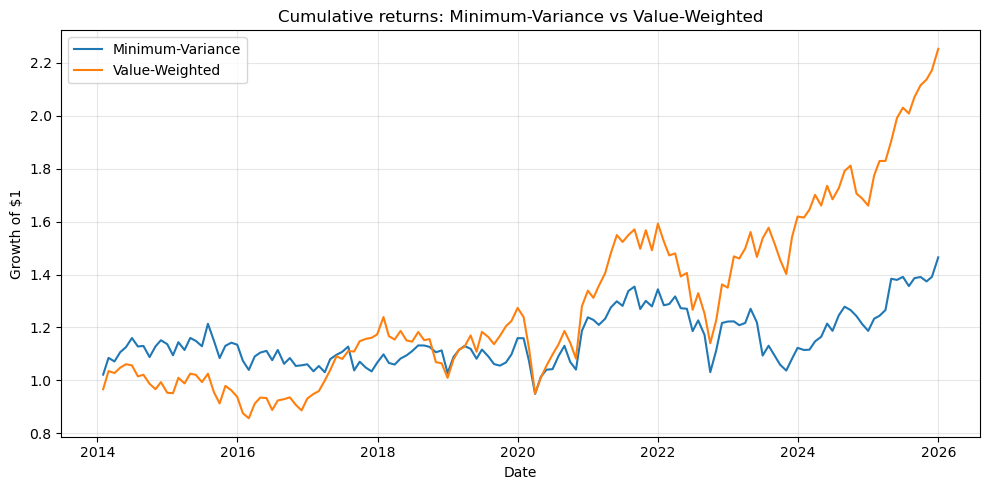

Done.
Outputs saved in: ..\results\outputs_vw

Return series check:
MV start: 2014-01-31 00:00:00
MV end:   2025-12-31 00:00:00
VW start: 2014-01-31 00:00:00
VW end:   2025-12-31 00:00:00
Number of months: 144

Summary statistics:
                  Annualized mean return  Annualized volatility  Sharpe ratio  Minimum monthly return  Maximum monthly return  Final cumulative index  Maximum drawdown  Number of monthly observations
Minimum-Variance                0.041307               0.137578      0.173146               -0.120155                0.140773                1.465022         -0.238762                           144.0
Value-Weighted                  0.080346               0.158463      0.397584               -0.152973                0.182863                2.253411         -0.283950                           144.0


In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This cell assumes that Sections 2.1 and 2.2 have already been executed and that the required objects are available in memory
required_objects = [
    "years",
    "investment_sets",
    "year_end_dec",
    "ri_panel",
    "ret_panel",
    "mv_oos_returns",
    "rf_series"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Missing object from previous sections: {obj}")

data_dir = Path("../data/cleaned")
mv_file = data_dir / "MV_M_cleaned.csv"

output_dir = Path("../results/outputs_vw")
output_dir.mkdir(parents=True, exist_ok=True)

csv_sep = ";"

# Parse calendar date headers from the raw dataset
def parse_calendar_date_headers(columns):
    cols = pd.Index(columns).astype(str).str.strip()
    return [pd.to_datetime(c, dayfirst=True) for c in cols]

# Convert panel values to numeric format
def to_numeric_panel(df):
    return df.apply(
        lambda col: pd.to_numeric(
            col.astype(str).str.replace(",", ".", regex=False),
            errors="coerce"
        )
    )

# Compute maximum drawdown from a cumulative return index
def max_drawdown(cumulative_index):
    running_max = cumulative_index.cummax()
    drawdown = cumulative_index / running_max - 1.0
    return drawdown.min()

# Compute standard portfolio performance statistics
def perf_stats(r, rf):

    r = r.replace([np.inf, -np.inf], np.nan).dropna().copy()

    r_month = r.copy()
    r_month.index = r_month.index.to_period("M")

    rf_month = rf.copy()
    rf_month.index = rf_month.index.to_period("M")

    rf_aligned = rf_month.reindex(r_month.index)

    if rf_aligned.isna().sum() > 0:
        raise ValueError("Some RF observations are missing after monthly alignment.")

    excess = r_month - rf_aligned

    ann_mean = 12 * r_month.mean()
    ann_vol = np.sqrt(12) * r_month.std(ddof=1)

    if excess.std(ddof=1) != 0:
        sharpe = np.sqrt(12) * excess.mean() / excess.std(ddof=1)
    else:
        sharpe = np.nan

    cumulative_index = (1 + r).cumprod()

    return pd.Series({
        "Annualized mean return": ann_mean,
        "Annualized volatility": ann_vol,
        "Sharpe ratio": sharpe,
        "Minimum monthly return": r.min(),
        "Maximum monthly return": r.max(),
        "Final cumulative index": cumulative_index.iloc[-1],
        "Maximum drawdown": max_drawdown(cumulative_index),
        "Number of monthly observations": r.shape[0]
    })

# Load monthly market capitalization data
mv_raw = pd.read_csv(mv_file, sep=csv_sep, na_values=["N/A", "#N/A", "nan", "NaN", ""])

mv_dates = parse_calendar_date_headers(list(mv_raw.columns[2:]))

mv_panel = mv_raw.copy()
mv_panel.columns = ["NAME", "ISIN"] + mv_dates
mv_panel = mv_panel.set_index(["ISIN", "NAME"])

mv_panel = to_numeric_panel(mv_panel)

# Restrict the panel to the same sample period used in the project
mv_panel = mv_panel.loc[:, mv_panel.columns <= pd.Timestamp("2025-12-31")]

# Keep only firms already used in the previous sections
common_mv_firms = mv_panel.index.intersection(ret_panel.index).intersection(ri_panel.index)
mv_panel = mv_panel.loc[common_mv_firms]

print("Monthly market cap panel shape:", mv_panel.shape)

# Build the same delisting map used in Section 2.2
# If a firm is flagged as dead/delisted/suspended and the first missing RI observation appears after the last valid price, we assign a −100% return
delist_pattern = re.compile(r"DEAD|DELIST|SUSP", re.IGNORECASE)
delist_event_month = {}

for asset in ri_panel.index:

    isin, name = asset

    if not delist_pattern.search(name):
        continue

    ri_series = ri_panel.loc[asset]
    valid_dates = ri_series.dropna().index

    if len(valid_dates) == 0:
        continue

    last_valid_date = valid_dates.max()
    future_dates = [d for d in ri_panel.columns if d > last_valid_date]

    if len(future_dates) == 0:
        continue

    first_missing_date = future_dates[0]

    if pd.isna(ri_series[first_missing_date]):
        delist_event_month[asset] = first_missing_date

vw_rows = []

all_months = sorted(ret_panel.columns)

# Construct the value-weighted portfolio returns
for Y in years:

    print(f"Formation year {Y} -> benchmark year {Y + 1}")

    eligible = investment_sets[Y]

    oos_months = [d for d in all_months if d.year == Y + 1]
    if len(oos_months) == 0:
        continue

    for dt in oos_months:

        current_loc = all_months.index(dt)
        prev_date = all_months[current_loc - 1]

        # Use previous-month market caps to compute portfolio weights
        caps_t = mv_panel.loc[eligible, prev_date].copy()
        r_t = ret_panel.loc[eligible, dt].copy()

        # Apply the same delisting treatment used in Section 2.2
        forced_delist_assets = []

        for asset in r_t.index:
            if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                forced_delist_assets.append(asset)

        if len(forced_delist_assets) > 0:
            r_t.loc[forced_delist_assets] = -1.0

        valid = (
            caps_t.notna()
            & np.isfinite(caps_t)
            & (caps_t > 0)
            & r_t.notna()
            & np.isfinite(r_t)
            & (r_t >= -1.0)
        )

        caps_t = caps_t[valid]
        r_t = r_t[valid]

        # Compute the value-weighted portfolio return
        if len(caps_t) == 0:
            port_ret = np.nan
        else:
            w_t = caps_t / caps_t.sum()
            port_ret = float((w_t * r_t).sum())

        vw_rows.append({
            "date": dt,
            "formation_year": Y,
            "oos_year": Y + 1,
            "portfolio_return": port_ret
        })

# Convert results into a time series of monthly returns
vw_monthly_returns = pd.DataFrame(vw_rows).sort_values("date").reset_index(drop=True)

if vw_monthly_returns.empty:
    raise ValueError("No value-weighted returns were produced.")

vw_monthly_returns["date"] = pd.to_datetime(vw_monthly_returns["date"])

# Restrict the final return series to the out-of-sample period
vw_monthly_returns = vw_monthly_returns[
    (vw_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (vw_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

vw_monthly_returns["cumulative_index"] = (1.0 + vw_monthly_returns["portfolio_return"]).cumprod()

vw_oos_returns = vw_monthly_returns.set_index("date")["portfolio_return"].sort_index()

# Combine minimum-variance and value-weighted returns
comparison_returns = pd.concat(
    [
        mv_oos_returns.rename("Minimum-Variance"),
        vw_oos_returns.rename("Value-Weighted")
    ],
    axis=1
).sort_index()

# Compute cumulative returns for both strategies
comparison_cumulative = (1.0 + comparison_returns).cumprod()

# Compute summary performance statistics
comparison_stats = pd.concat(
    [
        perf_stats(comparison_returns["Minimum-Variance"], rf_series).rename("Minimum-Variance"),
        perf_stats(comparison_returns["Value-Weighted"], rf_series).rename("Value-Weighted")
    ],
    axis=1
).T

# Save the main output files
comparison_returns.to_csv(output_dir / "comparison_monthly_returns.csv")
comparison_cumulative.to_csv(output_dir / "comparison_cumulative_returns.csv")
comparison_stats.to_csv(output_dir / "comparison_summary_stats.csv")

# Plot cumulative performance comparison
plt.figure(figsize=(10, 5))

plt.plot(
    comparison_cumulative.index,
    comparison_cumulative["Minimum-Variance"],
    label="Minimum-Variance"
)

plt.plot(
    comparison_cumulative.index,
    comparison_cumulative["Value-Weighted"],
    label="Value-Weighted"
)

plt.title("Cumulative returns: Minimum-Variance vs Value-Weighted")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "graph_cumulative_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

print("Done.")
print(f"Outputs saved in: {output_dir}")

print("\nReturn series check:")
print("MV start:", comparison_returns["Minimum-Variance"].dropna().index.min())
print("MV end:  ", comparison_returns["Minimum-Variance"].dropna().index.max())
print("VW start:", comparison_returns["Value-Weighted"].dropna().index.min())
print("VW end:  ", comparison_returns["Value-Weighted"].dropna().index.max())
print("Number of months:", comparison_returns.shape[0])

print("\nSummary statistics:")
print(comparison_stats.to_string())


### Interpretation of the results

The value-weighted portfolio delivers a higher annualized return and a higher Sharpe ratio than the minimum-variance portfolio over the **2014–2025** out-of-sample period. However, this improved performance comes with higher volatility and larger drawdowns.

By construction, the minimum-variance portfolio focuses on reducing total portfolio risk, which results in a smoother return path and smaller downside shocks. This can be observed in the lower annualized volatility and the smaller minimum monthly return compared to the value-weighted benchmark.

Overall, the results highlight the classic trade-off between risk reduction and return generation: while the minimum-variance strategy produces more stable returns, the value-weighted portfolio captures a larger share of market upside during the sample period.

## **Part II - Portfolio Allocation with Carbon Emission Reduction**


## 3) Allocation with a 50% Reduction in Carbon Emissions

This section adds the climate dimension to the portfolio allocation exercise. The investment universe remains the European universe defined in Part I, and the carbon variable is limited to **Scope 1 emissions**, as required for our group.

The objective is not to rebuild the universe from scratch. Instead, we keep the same eligible firms and add a carbon constraint to the portfolio construction problem. This makes the comparison with Part I meaningful: any difference in performance comes from the carbon objective and not from a different sample of firms.

We study two versions of the 50% reduction objective:

- a **minimum-variance portfolio with a 50% lower carbon footprint** than the unconstrained minimum-variance portfolio;
- a **value-weighted benchmark with a 50% lower carbon footprint**, obtained by minimizing tracking error relative to the original value-weighted benchmark.


### 3.1) Carbon Emissions

This subsection prepares the annual carbon variables used in the rest of the analysis. Since our group only uses **Scope 1 emissions**, the emissions panel comes from `CO2_S1_cleaned.csv`.

Carbon intensity is measured as Scope 1 emissions divided by revenues in million USD. Since revenues are reported in thousands USD in the dataset, revenues are divided by 1000 before computing carbon intensity.

We compute two portfolio-level indicators:

- **Weighted-Average Carbon Intensity (WACI)**: the weighted average of firm-level emissions per million USD of revenue;
- **Carbon Footprint (CF)**: the weighted average of firm-level emissions per million USD of market capitalization.

The carbon footprint is the key variable for the constraints in Sections 3.2, 3.3 and 4.1. WACI is also reported because it helps interpret which firms contribute most to portfolio carbon intensity.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

required_objects = [
    "years", "investment_sets", "sigma_dict", "ret_panel", "ri_panel",
    "mv_weights", "mv_oos_returns", "vw_oos_returns", "rf_series", "perf_stats"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Part I must be run first. Missing object: {obj}")

data_dir = Path("../data/cleaned")
output_dir = Path("../results/outputs_carbon")
output_dir.mkdir(parents=True, exist_ok=True)

csv_sep = ";"
ridge = 1e-8
solver_maxiter = 2000
ftol = 1e-12
starting_wealth_musd = 1.0

def load_annual_panel(file_name):
    raw = pd.read_csv(data_dir / file_name, sep=csv_sep, na_values=["N/A", "#N/A", "nan", "NaN", ""])
    panel = raw.copy()
    panel.columns = ["NAME", "ISIN"] + [int(c) for c in panel.columns[2:]]
    panel = panel.set_index(["ISIN", "NAME"])
    panel = panel.apply(lambda col: pd.to_numeric(col.astype(str).str.replace(",", ".", regex=False), errors="coerce"))

    # Annual carbon/accounting values are carried forward when later values are missing
    return panel.ffill(axis=1)

co2_s1_y = load_annual_panel("CO2_S1_cleaned.csv")
revenue_y = load_annual_panel("REVENUE_Y_cleaned.csv")
market_cap_y = load_annual_panel("MV_Y_cleaned.csv")

common_carbon_firms = (
    co2_s1_y.index
    .intersection(revenue_y.index)
    .intersection(market_cap_y.index)
    .intersection(ret_panel.index)
)

co2_s1_y = co2_s1_y.loc[common_carbon_firms]
revenue_y = revenue_y.loc[common_carbon_firms]
market_cap_y = market_cap_y.loc[common_carbon_firms]

print("Annual Scope 1 emissions panel shape:", co2_s1_y.shape)
print("Annual revenue panel shape:", revenue_y.shape)
print("Annual market cap panel shape:", market_cap_y.shape)

def normalize_weights(weights):
    w = weights.replace([np.inf, -np.inf], np.nan).dropna().copy()
    w = w[w > 0]
    if w.empty:
        return w
    return w / w.sum()

def get_carbon_inputs(asset_index, Y):
    assets = pd.Index(asset_index)

    emissions = co2_s1_y.reindex(assets)[Y]
    revenues = revenue_y.reindex(assets)[Y]
    market_caps = market_cap_y.reindex(assets)[Y]

    valid = (
        emissions.notna()
        & revenues.notna()
        & market_caps.notna()
        & np.isfinite(emissions)
        & np.isfinite(revenues)
        & np.isfinite(market_caps)
        & (revenues > 0)
        & (market_caps > 0)
    )

    emissions = emissions[valid]
    revenues = revenues[valid]
    market_caps = market_caps[valid]

    return pd.DataFrame({
        "emissions_scope1": emissions,
        "revenue_musd": revenues / 1000.0,
        "market_cap_musd": market_caps,
        "carbon_intensity": emissions / (revenues / 1000.0),
        "carbon_footprint_coeff": emissions / market_caps,
    })

def compute_carbon_metrics(weights, Y, strategy, wealth_musd=1.0):
    weights = normalize_weights(weights)
    carbon_inputs = get_carbon_inputs(weights.index, Y)

    w = weights.reindex(carbon_inputs.index).dropna()
    carbon_inputs = carbon_inputs.loc[w.index]
    w = w / w.sum()

    waci = float((w * carbon_inputs["carbon_intensity"]).sum())
    carbon_footprint = float((w * carbon_inputs["carbon_footprint_coeff"]).sum())

    return {
        "strategy": strategy,
        "formation_year": Y,
        "wealth_musd": wealth_musd,
        "WACI": waci,
        "carbon_footprint": carbon_footprint,
        "attributed_emissions_tonnes": wealth_musd * carbon_footprint,
        "n_assets_used": int(w.shape[0]),
        "n_assets_dropped": int(weights.shape[0] - w.shape[0]),
    }

def compute_waci_contributions(weights, Y, strategy):
    weights = normalize_weights(weights)
    carbon_inputs = get_carbon_inputs(weights.index, Y)
    w = weights.reindex(carbon_inputs.index).dropna()
    carbon_inputs = carbon_inputs.loc[w.index]
    w = w / w.sum()

    out = carbon_inputs.copy()
    out["weight"] = w
    out["WACI_contribution"] = out["weight"] * out["carbon_intensity"]
    out = out.reset_index()
    out["formation_year"] = Y
    out["strategy"] = strategy
    return out.sort_values("WACI_contribution", ascending=False)

def get_annual_vw_weights(Y, asset_index):
    caps = market_cap_y.reindex(asset_index)[Y]
    caps = caps.replace([np.inf, -np.inf], np.nan).dropna()
    caps = caps[caps > 0]
    if caps.empty:
        return caps
    return caps / caps.sum()

def wealth_by_formation_year(monthly_returns):
    wealth = {}
    current_wealth = starting_wealth_musd
    returns = monthly_returns.dropna().copy()

    for Y in years:
        wealth[Y] = current_wealth
        year_returns = returns[returns.index.year == Y + 1]
        current_wealth = current_wealth * float((1.0 + year_returns).prod())

    return wealth

def compute_active_share(portfolio_weights, benchmark_weights):
    assets = portfolio_weights.index.union(benchmark_weights.index)
    w = portfolio_weights.reindex(assets).fillna(0.0)
    b = benchmark_weights.reindex(assets).fillna(0.0)
    return 0.5 * float((w - b).abs().sum())

def compute_ex_post_tracking_error(portfolio_returns, benchmark_returns):
    aligned = pd.concat(
        [
            portfolio_returns.rename("portfolio"),
            benchmark_returns.rename("benchmark"),
        ],
        axis=1,
    ).dropna()

    tracking_difference = aligned["portfolio"] - aligned["benchmark"]
    return np.sqrt(12) * tracking_difference.std(ddof=1)

mv_wealth_by_year = wealth_by_formation_year(mv_oos_returns)
vw_wealth_by_year = wealth_by_formation_year(vw_oos_returns)

baseline_metric_rows = []
baseline_contribution_rows = []
vw_weights_by_year = {}

for Y in years:
    eligible = investment_sets[Y]
    mv_w = mv_weights[Y]
    vw_w = get_annual_vw_weights(Y, eligible)
    vw_weights_by_year[Y] = vw_w

    baseline_metric_rows.append(compute_carbon_metrics(mv_w, Y, "Minimum-Variance", mv_wealth_by_year[Y]))
    baseline_metric_rows.append(compute_carbon_metrics(vw_w, Y, "Value-Weighted", vw_wealth_by_year[Y]))

    baseline_contribution_rows.append(compute_waci_contributions(mv_w, Y, "Minimum-Variance"))
    baseline_contribution_rows.append(compute_waci_contributions(vw_w, Y, "Value-Weighted"))

baseline_carbon_metrics = pd.DataFrame(baseline_metric_rows)
baseline_waci_contributions = pd.concat(baseline_contribution_rows, ignore_index=True)

top10_waci_drivers = (
    baseline_waci_contributions
    .sort_values(["strategy", "formation_year", "WACI_contribution"], ascending=[True, True, False])
    .groupby(["strategy", "formation_year"])
    .head(10)
    .reset_index(drop=True)
)

baseline_carbon_metrics.to_csv(output_dir / "baseline_carbon_metrics.csv", index=False)
top10_waci_drivers.to_csv(output_dir / "top10_waci_drivers_by_year.csv", index=False)

print("Baseline carbon metrics:")
print(baseline_carbon_metrics.to_string(index=False))

latest_year = max(years)
print(f"\nTop WACI drivers in {latest_year}:")
print(
    top10_waci_drivers[top10_waci_drivers["formation_year"] == latest_year]
    [["strategy", "ISIN", "NAME", "weight", "carbon_intensity", "WACI_contribution"]]
    .to_string(index=False)
)

Annual Scope 1 emissions panel shape: (618, 27)
Annual revenue panel shape: (618, 27)
Annual market cap panel shape: (618, 27)
Baseline carbon metrics:
        strategy  formation_year  wealth_musd       WACI  carbon_footprint  attributed_emissions_tonnes  n_assets_used  n_assets_dropped
Minimum-Variance            2013     1.000000  26.457539         13.043699                    13.043699            252                 0
  Value-Weighted            2013     1.000000 109.846954        188.556022                   188.556022            477                 0
Minimum-Variance            2014     1.137004 249.173772       1744.277381                  1983.251104            266                 0
  Value-Weighted            2014     0.953306 102.903595        162.995287                   155.384446            493                 0
Minimum-Variance            2015     1.134839 120.536881        313.072648                   355.286916            289                 0
  Value-Weighted          

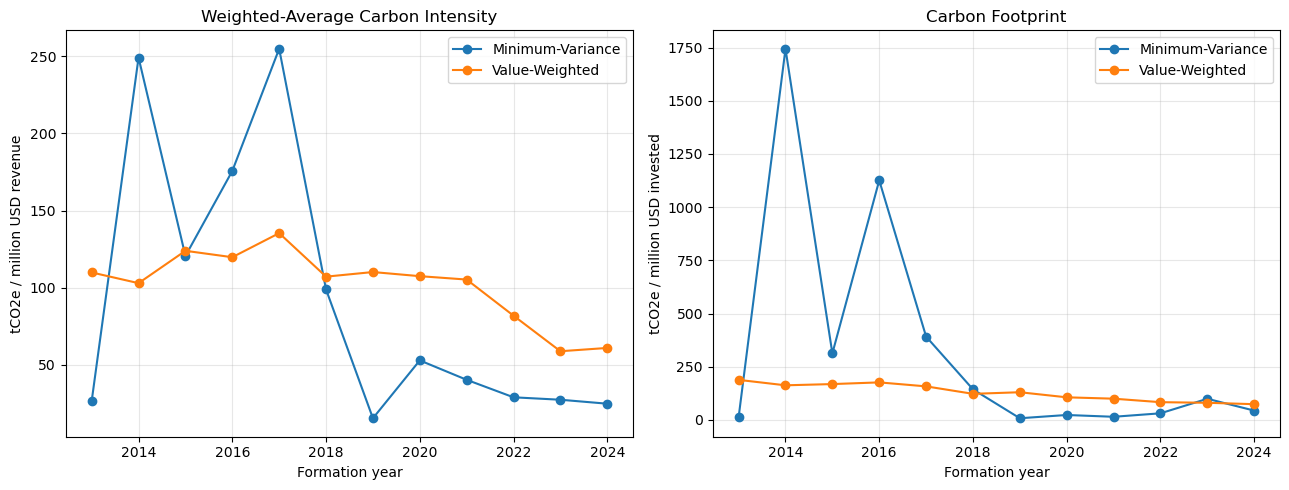

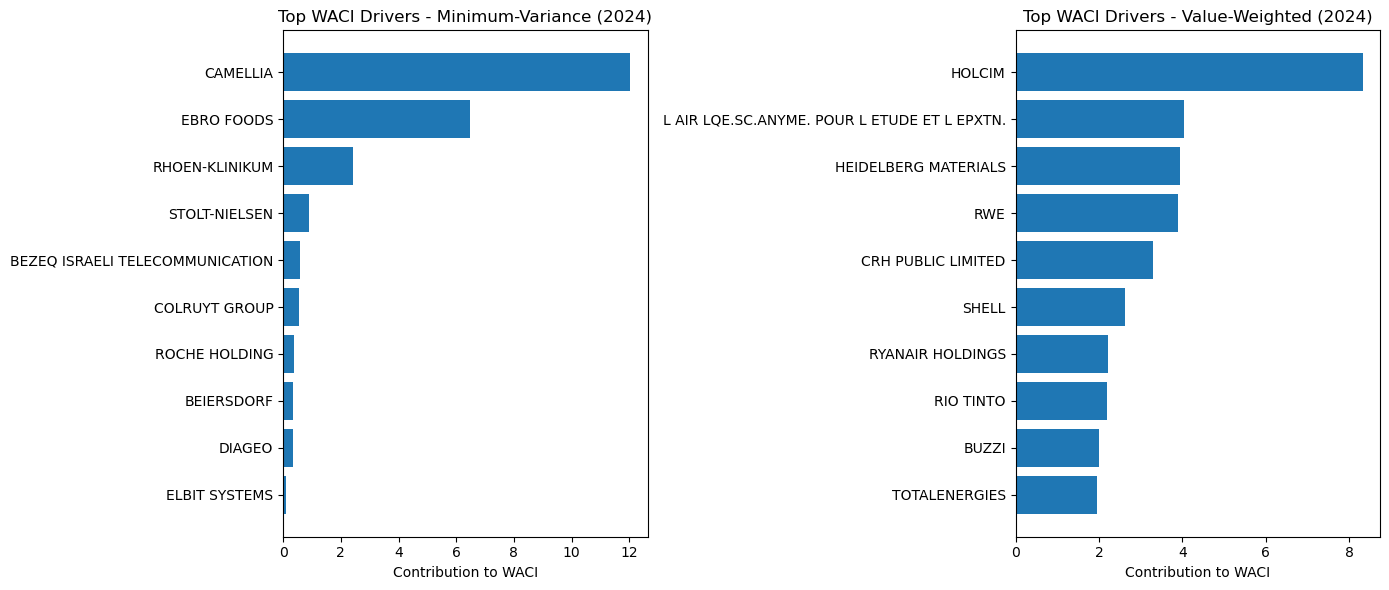

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for strategy, data in baseline_carbon_metrics.groupby("strategy"):
    axes[0].plot(data["formation_year"], data["WACI"], marker="o", label=strategy)
    axes[1].plot(data["formation_year"], data["carbon_footprint"], marker="o", label=strategy)

axes[0].set_title("Weighted-Average Carbon Intensity")
axes[0].set_xlabel("Formation year")
axes[0].set_ylabel("tCO2e / million USD revenue")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Carbon Footprint")
axes[1].set_xlabel("Formation year")
axes[1].set_ylabel("tCO2e / million USD invested")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "graph_baseline_waci_cf.png", dpi=300, bbox_inches="tight")
plt.show()

latest_top10 = top10_waci_drivers[top10_waci_drivers["formation_year"] == latest_year].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, strategy in zip(axes, ["Minimum-Variance", "Value-Weighted"]):
    data = latest_top10[latest_top10["strategy"] == strategy].copy()
    data = data.sort_values("WACI_contribution", ascending=True)
    ax.barh(data["NAME"], data["WACI_contribution"])
    ax.set_title(f"Top WACI Drivers - {strategy} ({latest_year})")
    ax.set_xlabel("Contribution to WACI")

plt.tight_layout()
plt.savefig(output_dir / "graph_top10_waci_drivers_latest_year.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of baseline carbon metrics

The baseline carbon plots help identify how carbon exposure differs before any decarbonization constraint is imposed. The minimum-variance portfolio can have very different carbon exposure from the value-weighted benchmark because it is driven by the covariance matrix and can be concentrated in a smaller number of stocks.

The top WACI contributors are useful for interpretation: a portfolio can have a moderate average weight in high-emission firms, but a small number of carbon-intensive companies can still explain a large part of total WACI. This is especially important when discussing why the unconstrained minimum-variance portfolio sometimes has large carbon footprint values.


### 3.2) Long-Only Portfolio with a Carbon Footprint Objective

We now construct a long-only minimum-variance portfolio with a carbon footprint at least 50% lower than the carbon footprint of the unconstrained minimum-variance portfolio.

For each formation year, the benchmark carbon footprint is first computed using the unconstrained minimum-variance weights from Part I. The optimization then solves the same minimum-variance problem as before, but with one additional inequality constraint:

$$CF_Y^{p} \leq 0.5 × CF_Y^{MV}$$

This means that the portfolio still minimizes variance, remains fully invested, and does not allow short selling, but it must also satisfy the 50% carbon footprint reduction target. The constraint is checked again after optimization to verify that the realized portfolio carbon footprint is below the required limit.


In [ ]:
def solve_minvar_with_cf_constraint(cov_matrix, carbon_coeff, cf_limit):
    assets = cov_matrix.index.intersection(carbon_coeff.dropna().index)
    Sigma_df = cov_matrix.loc[assets, assets].copy()
    c = carbon_coeff.loc[assets].astype(float)

    valid_assets = Sigma_df.index[Sigma_df.notna().all(axis=1)]
    Sigma_df = Sigma_df.loc[valid_assets, valid_assets]
    c = c.loc[valid_assets]

    n = Sigma_df.shape[0]
    if n == 0:
        raise ValueError("No assets are available for the carbon-constrained optimization.")
    if c.min() > cf_limit + 1e-10:
        raise ValueError("The carbon footprint constraint is infeasible for this year.")

    Sigma = Sigma_df.to_numpy(dtype=float) + ridge * np.eye(n)
    c_vec = c.to_numpy(dtype=float)
    carbon_scale = max(abs(cf_limit), float(np.nanmax(np.abs(c_vec))), 1.0)

    clean_asset = np.zeros(n)
    clean_asset[int(np.argmin(c_vec))] = 1.0

    # Start close to the unconstrained min-variance portfolio, then blend toward the cleanest asset if needed
    try:
        x0 = solve_minvar(Sigma_df).reindex(Sigma_df.index).fillna(0.0).to_numpy(dtype=float)
        x0 = x0 / x0.sum()
    except Exception:
        x0 = np.repeat(1 / n, n)

    if float(x0 @ c_vec) > cf_limit:
        for lam in np.linspace(0, 1, 501):
            candidate = (1 - lam) * x0 + lam * clean_asset
            if float(candidate @ c_vec) <= cf_limit:
                x0 = candidate / candidate.sum()
                break

    def objective(w):
        return float(w @ Sigma @ w)

    def objective_grad(w):
        return 2.0 * Sigma @ w

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0, "jac": lambda w: np.ones_like(w)},
        {
            "type": "ineq",
            "fun": lambda w: (cf_limit - float(w @ c_vec)) / carbon_scale,
            "jac": lambda w: -c_vec / carbon_scale,
        },
    ]

    res = minimize(
        objective,
        x0=x0,
        jac=objective_grad,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints=constraints,
        options={"maxiter": solver_maxiter * 5, "ftol": 1e-9, "disp": False},
    )

    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    w = pd.Series(res.x, index=Sigma_df.index)
    w[w < 1e-12] = 0.0
    return w / w.sum()

def simulate_annual_strategy_returns(weights_by_year, strategy_name):
    rows = []
    all_months = sorted(ret_panel.columns)

    for Y in years:
        print(f"{strategy_name}: formation year {Y} -> OOS year {Y + 1}")
        current_weights = normalize_weights(weights_by_year[Y])
        oos_months = [d for d in all_months if d.year == Y + 1]

        for dt in oos_months:
            r_t = ret_panel.loc[current_weights.index, dt].copy()

            if "delist_event_month" in globals():
                forced_delist_assets = []
                for asset in r_t.index:
                    if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                        forced_delist_assets.append(asset)
                if len(forced_delist_assets) > 0:
                    r_t.loc[forced_delist_assets] = -1.0

            valid = r_t.notna() & np.isfinite(r_t) & current_weights.notna()
            r_t = r_t[valid]
            w_t = current_weights[valid]

            if len(w_t) == 0:
                rows.append({"date": dt, "formation_year": Y, "oos_year": Y + 1, "portfolio_return": np.nan})
                continue

            w_t = w_t / w_t.sum()
            rp_t = float((w_t * r_t).sum())
            rows.append({"date": dt, "formation_year": Y, "oos_year": Y + 1, "portfolio_return": rp_t})

            denom = 1.0 + rp_t
            if abs(denom) > 1e-12:
                current_weights = w_t * (1.0 + r_t) / denom
                current_weights = current_weights / current_weights.sum()
            else:
                current_weights = pd.Series(np.repeat(1 / len(w_t), len(w_t)), index=w_t.index)

    monthly_returns = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    monthly_returns["date"] = pd.to_datetime(monthly_returns["date"])
    monthly_returns = monthly_returns[
        (monthly_returns["date"] >= pd.Timestamp("2014-01-01"))
        & (monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
    ].copy()
    monthly_returns["cumulative_index"] = (1.0 + monthly_returns["portfolio_return"]).cumprod()
    return monthly_returns

mv50_weights = {}
mv50_constraint_rows = []

for Y in years:
    Sigma = sigma_dict[Y].copy()
    carbon_inputs = get_carbon_inputs(Sigma.index, Y)
    carbon_coeff = carbon_inputs["carbon_footprint_coeff"]

    mv_cf = compute_carbon_metrics(mv_weights[Y], Y, "Minimum-Variance")["carbon_footprint"]
    cf_limit = 0.5 * mv_cf
    w = solve_minvar_with_cf_constraint(Sigma, carbon_coeff, cf_limit)
    mv50_weights[Y] = w

    realized_cf = compute_carbon_metrics(w, Y, "Minimum-Variance 50% CF Reduction")["carbon_footprint"]
    mv50_constraint_rows.append({
        "formation_year": Y,
        "baseline_cf": mv_cf,
        "cf_limit": cf_limit,
        "realized_cf": realized_cf,
        "n_assets": len(w),
    })

mv50_constraint_check = pd.DataFrame(mv50_constraint_rows)
mv50_monthly_returns = simulate_annual_strategy_returns(mv50_weights, "Minimum-Variance 50% CF Reduction")
mv50_oos_returns = mv50_monthly_returns.set_index("date")["portfolio_return"].sort_index()
mv50_ex_post_te_vs_minvar = compute_ex_post_tracking_error(mv50_oos_returns, mv_oos_returns)
mv50_wealth_by_year = wealth_by_formation_year(mv50_oos_returns)

mv50_carbon_metrics = pd.DataFrame([
    compute_carbon_metrics(mv50_weights[Y], Y, "Minimum-Variance 50% CF Reduction", mv50_wealth_by_year[Y])
    for Y in years
])

minvar_50_returns = pd.concat(
    [mv_oos_returns.rename("Minimum-Variance"), mv50_oos_returns.rename("Minimum-Variance 50% CF Reduction")],
    axis=1,
).sort_index()

minvar_50_cumulative = (1.0 + minvar_50_returns).cumprod()
minvar_50_stats = pd.concat(
    [
        perf_stats(minvar_50_returns["Minimum-Variance"], rf_series).rename("Minimum-Variance"),
        perf_stats(minvar_50_returns["Minimum-Variance 50% CF Reduction"], rf_series).rename("Minimum-Variance 50% CF Reduction"),
    ],
    axis=1,
).T

minvar_50_stats["Ex-post tracking error vs benchmark"] = np.nan
minvar_50_stats.loc["Minimum-Variance", "Ex-post tracking error vs benchmark"] = 0.0
minvar_50_stats.loc["Minimum-Variance 50% CF Reduction", "Ex-post tracking error vs benchmark"] = mv50_ex_post_te_vs_minvar

mv50_weights_long = pd.concat(
    [w.rename("weight").reset_index().assign(formation_year=Y, oos_year=Y + 1) for Y, w in mv50_weights.items()],
    ignore_index=True,
)


print("Carbon constraint check for the minimum-variance 50% reduction portfolio:")
print(mv50_constraint_check.to_string(index=False))
print("\nPerformance comparison:")
print(minvar_50_stats.to_string())


Minimum-Variance 50% CF Reduction: formation year 2013 -> OOS year 2014
Minimum-Variance 50% CF Reduction: formation year 2014 -> OOS year 2015
Minimum-Variance 50% CF Reduction: formation year 2015 -> OOS year 2016
Minimum-Variance 50% CF Reduction: formation year 2016 -> OOS year 2017
Minimum-Variance 50% CF Reduction: formation year 2017 -> OOS year 2018
Minimum-Variance 50% CF Reduction: formation year 2018 -> OOS year 2019
Minimum-Variance 50% CF Reduction: formation year 2019 -> OOS year 2020
Minimum-Variance 50% CF Reduction: formation year 2020 -> OOS year 2021
Minimum-Variance 50% CF Reduction: formation year 2021 -> OOS year 2022
Minimum-Variance 50% CF Reduction: formation year 2022 -> OOS year 2023
Minimum-Variance 50% CF Reduction: formation year 2023 -> OOS year 2024
Minimum-Variance 50% CF Reduction: formation year 2024 -> OOS year 2025
Carbon constraint check for the minimum-variance 50% reduction portfolio:
 formation_year  baseline_cf   cf_limit  realized_cf  n_assets

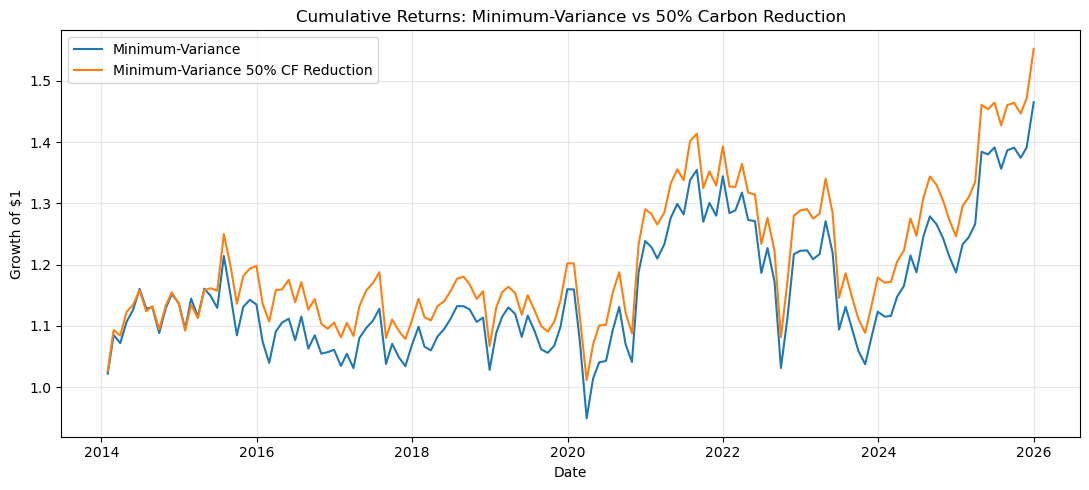

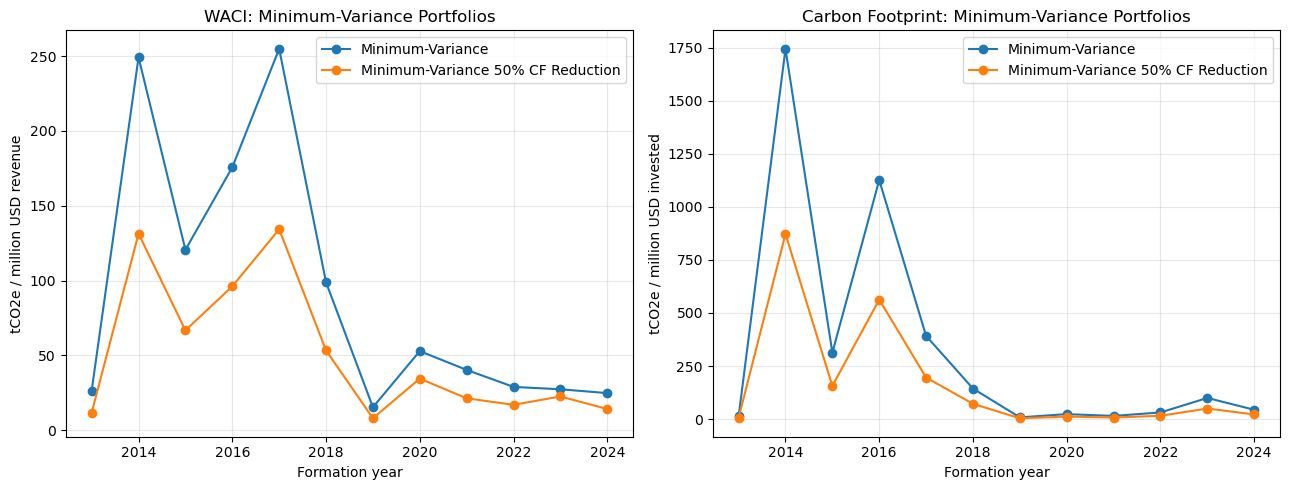

Largest weight reductions in 2024:
        ISIN                            NAME  Minimum-Variance  Minimum-Variance 50% CF Reduction  weight_change
GB0001667087                        CAMELLIA          0.028238                           0.005473      -0.022765
DE0005200000                      BEIERSDORF          0.050075                           0.043540      -0.006534
CH0008742519                    SWISSCOM 'R'          0.067528                           0.062523      -0.005006
ES0112501012                      EBRO FOODS          0.111979                           0.108367      -0.003612
IL0002300114 BEZEQ ISRAELI TELECOMMUNICATION          0.060471                           0.056940      -0.003531
BMG850801025                   STOLT-NIELSEN          0.001566                           0.000000      -0.001566
BE0974256852                   COLRUYT GROUP          0.076295                           0.074777      -0.001517
CH0044328745                           CHUBB          0.00113

In [ ]:
plt.figure(figsize=(11, 5))
for col in minvar_50_cumulative.columns:
    plt.plot(minvar_50_cumulative.index, minvar_50_cumulative[col], label=col)

plt.title("Cumulative Returns: Minimum-Variance vs 50% Carbon Reduction")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "graph_cumulative_minvar_50.png", dpi=300, bbox_inches="tight")
plt.show()

mv_carbon_compare = pd.concat(
    [baseline_carbon_metrics[baseline_carbon_metrics["strategy"] == "Minimum-Variance"], mv50_carbon_metrics],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for strategy, data in mv_carbon_compare.groupby("strategy"):
    axes[0].plot(data["formation_year"], data["WACI"], marker="o", label=strategy)
    axes[1].plot(data["formation_year"], data["carbon_footprint"], marker="o", label=strategy)

axes[0].set_title("WACI: Minimum-Variance Portfolios")
axes[0].set_xlabel("Formation year")
axes[0].set_ylabel("tCO2e / million USD revenue")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Carbon Footprint: Minimum-Variance Portfolios")
axes[1].set_xlabel("Formation year")
axes[1].set_ylabel("tCO2e / million USD invested")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "graph_carbon_minvar_50.png", dpi=300, bbox_inches="tight")
plt.show()

latest_mv = mv_weights[latest_year].rename("Minimum-Variance")
latest_mv50 = mv50_weights[latest_year].rename("Minimum-Variance 50% CF Reduction")
mv_composition_change = pd.concat([latest_mv, latest_mv50], axis=1).fillna(0)
mv_composition_change["weight_change"] = (
    mv_composition_change["Minimum-Variance 50% CF Reduction"] - mv_composition_change["Minimum-Variance"]
)
mv_composition_change = mv_composition_change.reset_index().sort_values("weight_change")

print(f"Largest weight reductions in {latest_year}:")
print(mv_composition_change.head(10).to_string(index=False))
print(f"\nLargest weight increases in {latest_year}:")
print(mv_composition_change.tail(10).sort_values("weight_change", ascending=False).to_string(index=False))


### Interpretation of the minimum-variance 50% reduction portfolio

The 50% carbon constraint is binding in several years, which means the optimizer must move away from the unconstrained minimum-variance solution. The resulting portfolio still targets low variance, but it also avoids part of the carbon exposure that was present in the unconstrained minimum-variance allocation.

Because the minimum-variance portfolio is naturally concentrated, the carbon constraint can have a visible effect on the composition of the portfolio. The latest-year composition table shows which holdings are reduced or increased the most to meet the carbon objective.


### 3.3) Tracking Error Minimization

The second decarbonization strategy takes the point of view of an otherwise passive investor. The objective is to stay as close as possible to the value-weighted benchmark while imposing a 50% reduction in carbon footprint.

For each formation year, we start from the value-weighted benchmark and solve a tracking-error minimization problem. The active weights are the difference between the optimized portfolio weights and the benchmark weights. The optimizer therefore tries to keep those active weights as small as possible in risk terms.

The carbon constraint is:

$$CF_Y^{p} \leq 0.5 × CF_Y^{VW}$$

where $CF_Y^{VW}$ is the carbon footprint of the value-weighted benchmark in the same formation year.

The optimizer returns an **ex-ante annualized tracking error** for each formation year. This value is stored in the consolidated constraint-check table. After simulating the out-of-sample monthly returns, we also report an **ex-post tracking error**, computed from the realized monthly return difference relative to the benchmark. The two measures answer different questions: ex-ante TE describes the optimized portfolio at formation, while ex-post TE describes what happened during the realized out-of-sample period.


In [ ]:
def solve_tracking_error_with_cf_constraint(cov_matrix, benchmark_weights, carbon_coeff, cf_limit):
    assets = cov_matrix.index.intersection(benchmark_weights.index).intersection(carbon_coeff.dropna().index)
    Sigma_df = cov_matrix.loc[assets, assets].copy()
    b = benchmark_weights.loc[assets].astype(float)
    c = carbon_coeff.loc[assets].astype(float)

    valid_assets = Sigma_df.index[Sigma_df.notna().all(axis=1)]
    Sigma_df = Sigma_df.loc[valid_assets, valid_assets]
    b = b.loc[valid_assets]
    c = c.loc[valid_assets]
    b = b / b.sum()

    n = Sigma_df.shape[0]
    if n == 0:
        raise ValueError("No assets are available for the tracking-error optimization.")
    if c.min() > cf_limit + 1e-10:
        raise ValueError("The carbon footprint constraint is infeasible for this year.")

    Sigma = Sigma_df.to_numpy(dtype=float) + ridge * np.eye(n)
    b_vec = b.to_numpy(dtype=float)
    c_vec = c.to_numpy(dtype=float)

    carbon_scale = max(abs(cf_limit), float(np.nanmax(np.abs(c_vec))), 1.0)

    clean_asset = np.zeros(n)
    clean_asset[int(np.argmin(c_vec))] = 1.0

    x0 = b_vec.copy()
    if float(x0 @ c_vec) > cf_limit:
        for lam in np.linspace(0, 1, 501):
            candidate = (1 - lam) * b_vec + lam * clean_asset
            if float(candidate @ c_vec) <= cf_limit:
                x0 = candidate / candidate.sum()
                break

    def objective(w):
        active = w - b_vec
        return float(active @ Sigma @ active)

    def objective_grad(w):
        active = w - b_vec
        return 2.0 * Sigma @ active

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0, "jac": lambda w: np.ones_like(w)},
        {
            "type": "ineq",
            "fun": lambda w: (cf_limit - float(w @ c_vec)) / carbon_scale,
            "jac": lambda w: -c_vec / carbon_scale,
        },
    ]

    res = minimize(
        objective,
        x0=x0,
        jac=objective_grad,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints=constraints,
        options={"maxiter": solver_maxiter * 5, "ftol": 1e-9, "disp": False},
    )

    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    w = pd.Series(res.x, index=Sigma_df.index)
    w[w < 1e-12] = 0.0
    w = w / w.sum()

    te_monthly = np.sqrt(max(objective(w.to_numpy()), 0.0))
    te_annualized = np.sqrt(12) * te_monthly
    return w, te_annualized

vw50_weights = {}
vw50_constraint_rows = []

for Y in years:
    Sigma = sigma_dict[Y].copy()
    eligible = investment_sets[Y]
    vw_w = get_annual_vw_weights(Y, eligible)
    carbon_inputs = get_carbon_inputs(Sigma.index, Y)
    carbon_coeff = carbon_inputs["carbon_footprint_coeff"]

    vw_cf = compute_carbon_metrics(vw_w, Y, "Value-Weighted")["carbon_footprint"]
    cf_limit = 0.5 * vw_cf
    w, te_ann = solve_tracking_error_with_cf_constraint(Sigma, vw_w, carbon_coeff, cf_limit)
    vw50_weights[Y] = w

    realized_cf = compute_carbon_metrics(w, Y, "Value-Weighted 50% CF Reduction")["carbon_footprint"]
    vw50_constraint_rows.append({
        "formation_year": Y,
        "benchmark_cf": vw_cf,
        "cf_limit": cf_limit,
        "realized_cf": realized_cf,
        "active_share_vs_benchmark": compute_active_share(w, vw_w),
        "ex_ante_tracking_error_annualized": te_ann,
        "n_assets": len(w),
    })

vw50_constraint_check = pd.DataFrame(vw50_constraint_rows)
vw50_monthly_returns = simulate_annual_strategy_returns(vw50_weights, "Value-Weighted 50% CF Reduction")
vw50_oos_returns = vw50_monthly_returns.set_index("date")["portfolio_return"].sort_index()
# Store realized tracking error after the out-of-sample simulation
vw50_ex_post_te_vs_benchmark = compute_ex_post_tracking_error(vw50_oos_returns, vw_oos_returns)
vw50_constraint_check["ex_post_tracking_error_vs_benchmark"] = vw50_ex_post_te_vs_benchmark
vw50_wealth_by_year = wealth_by_formation_year(vw50_oos_returns)

vw50_carbon_metrics = pd.DataFrame([
    compute_carbon_metrics(vw50_weights[Y], Y, "Value-Weighted 50% CF Reduction", vw50_wealth_by_year[Y])
    for Y in years
])

vw_50_returns = pd.concat(
    [vw_oos_returns.rename("Value-Weighted"), vw50_oos_returns.rename("Value-Weighted 50% CF Reduction")],
    axis=1,
).sort_index()
vw_50_cumulative = (1.0 + vw_50_returns).cumprod()
vw_50_stats = pd.concat(
    [
        perf_stats(vw_50_returns["Value-Weighted"], rf_series).rename("Value-Weighted"),
        perf_stats(vw_50_returns["Value-Weighted 50% CF Reduction"], rf_series).rename("Value-Weighted 50% CF Reduction"),
    ],
    axis=1,
).T

vw_50_stats["Ex-post tracking error vs benchmark"] = np.nan
vw_50_stats.loc["Value-Weighted", "Ex-post tracking error vs benchmark"] = 0.0
vw_50_stats.loc["Value-Weighted 50% CF Reduction", "Ex-post tracking error vs benchmark"] = vw50_ex_post_te_vs_benchmark

vw50_weights_long = pd.concat(
    [w.rename("weight").reset_index().assign(formation_year=Y, oos_year=Y + 1) for Y, w in vw50_weights.items()],
    ignore_index=True,
)


print("Carbon constraint check for the value-weighted 50% reduction portfolio:")
print(vw50_constraint_check.to_string(index=False))
print("\nPerformance comparison:")
print(vw_50_stats.to_string())


Value-Weighted 50% CF Reduction: formation year 2013 -> OOS year 2014
Value-Weighted 50% CF Reduction: formation year 2014 -> OOS year 2015
Value-Weighted 50% CF Reduction: formation year 2015 -> OOS year 2016
Value-Weighted 50% CF Reduction: formation year 2016 -> OOS year 2017
Value-Weighted 50% CF Reduction: formation year 2017 -> OOS year 2018
Value-Weighted 50% CF Reduction: formation year 2018 -> OOS year 2019
Value-Weighted 50% CF Reduction: formation year 2019 -> OOS year 2020
Value-Weighted 50% CF Reduction: formation year 2020 -> OOS year 2021
Value-Weighted 50% CF Reduction: formation year 2021 -> OOS year 2022
Value-Weighted 50% CF Reduction: formation year 2022 -> OOS year 2023
Value-Weighted 50% CF Reduction: formation year 2023 -> OOS year 2024
Value-Weighted 50% CF Reduction: formation year 2024 -> OOS year 2025
Carbon constraint check for the value-weighted 50% reduction portfolio:
 formation_year  benchmark_cf  cf_limit  realized_cf  active_share_vs_benchmark  ex_ante

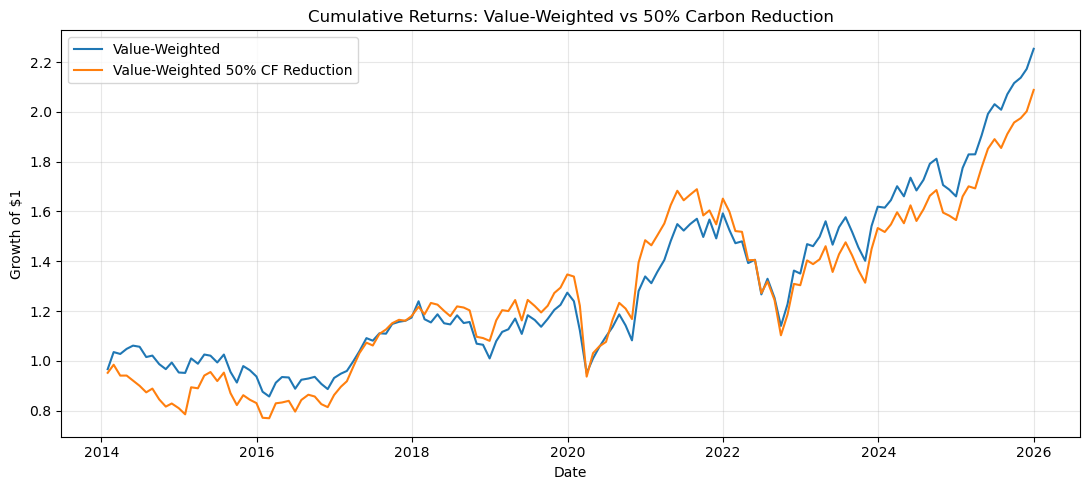

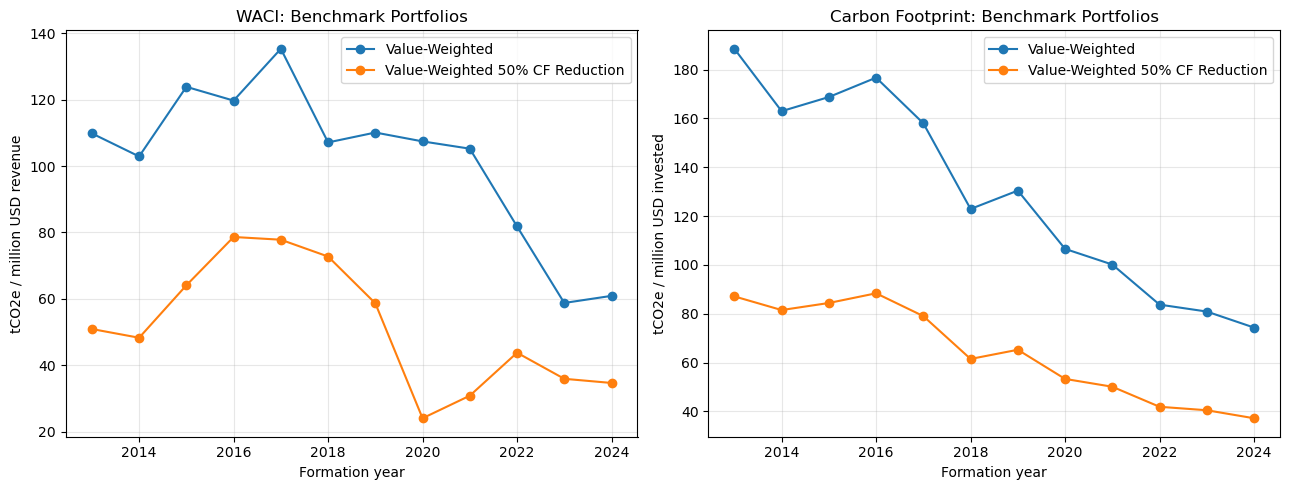

Largest benchmark weight reductions in 2024:
        ISIN               NAME  Value-Weighted  Value-Weighted 50% CF Reduction  weight_change
FR0000121014               LVMH        0.035135                         0.022292      -0.012843
FR0000120321            L'OREAL        0.021557                         0.010706      -0.010851
DE0005557508   DEUTSCHE TELEKOM        0.010176                         0.001083      -0.009093
CH0244767585          UBS GROUP        0.008596                         0.000083      -0.008513
FR0000121972 SCHNEIDER ELECTRIC        0.009735                         0.001885      -0.007850
GB0005405286      HSBC HOLDINGS        0.012381                         0.004851      -0.007530
IE00B4BNMY34  ACCENTURE CLASS A        0.020723                         0.013206      -0.007517
NO0010096985            EQUINOR        0.007103                         0.000126      -0.006977
FR0000121667   ESSILORLUXOTTICA        0.007386                         0.000441      -0.00

In [ ]:
plt.figure(figsize=(11, 5))
for col in vw_50_cumulative.columns:
    plt.plot(vw_50_cumulative.index, vw_50_cumulative[col], label=col)

plt.title("Cumulative Returns: Value-Weighted vs 50% Carbon Reduction")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "graph_cumulative_vw_50.png", dpi=300, bbox_inches="tight")
plt.show()

vw_carbon_compare = pd.concat(
    [baseline_carbon_metrics[baseline_carbon_metrics["strategy"] == "Value-Weighted"], vw50_carbon_metrics],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for strategy, data in vw_carbon_compare.groupby("strategy"):
    axes[0].plot(data["formation_year"], data["WACI"], marker="o", label=strategy)
    axes[1].plot(data["formation_year"], data["carbon_footprint"], marker="o", label=strategy)

axes[0].set_title("WACI: Benchmark Portfolios")
axes[0].set_xlabel("Formation year")
axes[0].set_ylabel("tCO2e / million USD revenue")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Carbon Footprint: Benchmark Portfolios")
axes[1].set_xlabel("Formation year")
axes[1].set_ylabel("tCO2e / million USD invested")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "graph_carbon_vw_50.png", dpi=300, bbox_inches="tight")
plt.show()

latest_vw = vw_weights_by_year[latest_year].rename("Value-Weighted")
latest_vw50 = vw50_weights[latest_year].rename("Value-Weighted 50% CF Reduction")
vw_composition_change = pd.concat([latest_vw, latest_vw50], axis=1).fillna(0)
vw_composition_change["weight_change"] = (
    vw_composition_change["Value-Weighted 50% CF Reduction"] - vw_composition_change["Value-Weighted"]
)
vw_composition_change = vw_composition_change.reset_index().sort_values("weight_change")

print(f"Largest benchmark weight reductions in {latest_year}:")
print(vw_composition_change.head(10).to_string(index=False))
print(f"\nLargest benchmark weight increases in {latest_year}:")
print(vw_composition_change.tail(10).sort_values("weight_change", ascending=False).to_string(index=False))


### Interpretation of the value-weighted 50% reduction portfolio

This portfolio is designed to stay close to the value-weighted benchmark while cutting carbon footprint by 50%. The tracking-error objective means that the optimizer tries to make the smallest risk-based changes needed to satisfy the carbon constraint.

The active share and ex-post tracking error help measure how far the decarbonized portfolio moves away from the original benchmark. A higher value indicates that the carbon target requires a larger reallocation away from the value-weighted portfolio.


### 3.4) Comparison of Portfolios

This subsection compares the two 50% carbon reduction approaches. Both strategies impose the same type of carbon footprint reduction, but they start from different reference portfolios.

For the minimum-variance investor, the constraint changes a portfolio that is already optimized for risk. For the otherwise passive investor, the main cost is measured through the deviation from the value-weighted benchmark. This is why the comparison looks at both financial performance and carbon metrics.

The key question is whether a strong reduction in carbon footprint can be achieved without a large deterioration in annualized return, volatility, Sharpe ratio, drawdown, or tracking error.


In [ ]:
all_50_stats = pd.concat([minvar_50_stats, vw_50_stats], axis=0)
all_50_carbon_metrics = pd.concat(
    [baseline_carbon_metrics, mv50_carbon_metrics, vw50_carbon_metrics],
    ignore_index=True,
)


print("Summary statistics for baseline and 50% reduction portfolios:")
print(all_50_stats.to_string())
print("\nAverage carbon metrics by strategy:")
print(
    all_50_carbon_metrics
    .groupby("strategy")[["WACI", "carbon_footprint", "attributed_emissions_tonnes"]]
    .mean()
    .sort_values("carbon_footprint")
    .to_string()
)


Summary statistics for baseline and 50% reduction portfolios:
                                   Annualized mean return  Annualized volatility  Sharpe ratio  Minimum monthly return  Maximum monthly return  Final cumulative index  Maximum drawdown  Number of monthly observations  Ex-post tracking error vs benchmark
Minimum-Variance                                 0.041307               0.137578      0.173146               -0.120155                0.140773                1.465022         -0.238762                           144.0                             0.000000
Minimum-Variance 50% CF Reduction                0.045657               0.134102      0.210047               -0.115213                0.133309                1.552246         -0.235067                           144.0                             0.016424
Value-Weighted                                   0.080346               0.158463      0.397584               -0.152973                0.182863                2.253411         -

### Interpretation of the 50% reduction comparison

The comparison shows that the same carbon target can have different implications depending on the starting portfolio. The minimum-variance version mainly shows how a risk-minimizing allocation reacts to a carbon constraint, while the value-weighted version shows the cost of decarbonizing a market-like benchmark.

In the report, the most important elements to comment on are the change in Sharpe ratio, the final cumulative index, the maximum drawdown, and the ex-post tracking error versus the benchmark.


## 4) Portfolio Allocation with a Net Zero Objective

The final strategy keeps the otherwise passive investor perspective. The portfolio is constructed by minimizing tracking error relative to the value-weighted benchmark, while imposing a carbon footprint path that declines by 10% per year from the initial 2013 value-weighted carbon footprint.

This is different from the fixed 50% reduction rule. The 50% rule compares the optimized portfolio to the benchmark carbon footprint in the same year. The Net Zero rule instead uses a fixed starting point and forces the carbon budget to decline over time. It is therefore closer to a transition-path objective.


### 4.1) Net Zero Portfolio

The carbon footprint constraint is dynamic. For each formation year $Y$, the maximum allowed carbon footprint is:

$$CF_Y^{p} \leq (1 - 	heta)^{Y - Y_0 + 1} CF^{VW}_{Y_0}$$

where $Y_0 = 2013$ and $	heta = 10\%$.

In practice, this means that the 2013 value-weighted carbon footprint is used as the fixed reference level. Each following formation year receives a progressively lower carbon budget. The optimization then minimizes tracking error relative to the value-weighted benchmark while respecting this decreasing carbon footprint limit.

As in the 50% reduction strategy, the annual constraint-check table reports the **ex-ante annualized tracking error** returned by the optimizer for each formation year. The final performance table keeps the **ex-post tracking error**, measured from realized monthly returns over the out-of-sample period.


In [ ]:
theta = 0.10
Y0 = min(years)

initial_vw_cf = baseline_carbon_metrics[
    (baseline_carbon_metrics["strategy"] == "Value-Weighted")
    & (baseline_carbon_metrics["formation_year"] == Y0)
]["carbon_footprint"].iloc[0]

netzero_weights = {}
netzero_constraint_rows = []

for Y in years:
    Sigma = sigma_dict[Y].copy()
    eligible = investment_sets[Y]
    vw_w = get_annual_vw_weights(Y, eligible)
    carbon_inputs = get_carbon_inputs(Sigma.index, Y)
    carbon_coeff = carbon_inputs["carbon_footprint_coeff"]

    vw_cf = compute_carbon_metrics(vw_w, Y, "Value-Weighted")["carbon_footprint"]
    cf_limit = ((1.0 - theta) ** (Y - Y0 + 1)) * initial_vw_cf
    w, te_ann = solve_tracking_error_with_cf_constraint(Sigma, vw_w, carbon_coeff, cf_limit)
    netzero_weights[Y] = w

    realized_cf = compute_carbon_metrics(w, Y, "Value-Weighted Net Zero")["carbon_footprint"]
    netzero_constraint_rows.append({
        "formation_year": Y,
        "benchmark_cf": vw_cf,
        "net_zero_cf_limit": cf_limit,
        "realized_cf": realized_cf,
        "active_share_vs_benchmark": compute_active_share(w, vw_w),
        "ex_ante_tracking_error_annualized": te_ann,
        "n_assets": len(w),
    })

netzero_constraint_check = pd.DataFrame(netzero_constraint_rows)
netzero_monthly_returns = simulate_annual_strategy_returns(netzero_weights, "Value-Weighted Net Zero")
netzero_oos_returns = netzero_monthly_returns.set_index("date")["portfolio_return"].sort_index()
# Store realized tracking error after the out-of-sample simulation
netzero_ex_post_te_vs_benchmark = compute_ex_post_tracking_error(netzero_oos_returns, vw_oos_returns)
netzero_constraint_check["ex_post_tracking_error_vs_benchmark"] = netzero_ex_post_te_vs_benchmark
netzero_wealth_by_year = wealth_by_formation_year(netzero_oos_returns)

netzero_carbon_metrics = pd.DataFrame([
    compute_carbon_metrics(netzero_weights[Y], Y, "Value-Weighted Net Zero", netzero_wealth_by_year[Y])
    for Y in years
])

netzero_returns = pd.concat(
    [
        vw_oos_returns.rename("Value-Weighted"),
        vw50_oos_returns.rename("Value-Weighted 50% CF Reduction"),
        netzero_oos_returns.rename("Value-Weighted Net Zero"),
    ],
    axis=1,
).sort_index()

netzero_cumulative = (1.0 + netzero_returns).cumprod()
netzero_stats = pd.concat(
    [
        perf_stats(netzero_returns["Value-Weighted"], rf_series).rename("Value-Weighted"),
        perf_stats(netzero_returns["Value-Weighted 50% CF Reduction"], rf_series).rename("Value-Weighted 50% CF Reduction"),
        perf_stats(netzero_returns["Value-Weighted Net Zero"], rf_series).rename("Value-Weighted Net Zero"),
    ],
    axis=1,
).T

netzero_stats["Ex-post tracking error vs benchmark"] = np.nan
netzero_stats.loc["Value-Weighted", "Ex-post tracking error vs benchmark"] = 0.0
netzero_stats.loc["Value-Weighted 50% CF Reduction", "Ex-post tracking error vs benchmark"] = vw50_ex_post_te_vs_benchmark
netzero_stats.loc["Value-Weighted Net Zero", "Ex-post tracking error vs benchmark"] = netzero_ex_post_te_vs_benchmark

netzero_weights_long = pd.concat(
    [w.rename("weight").reset_index().assign(formation_year=Y, oos_year=Y + 1) for Y, w in netzero_weights.items()],
    ignore_index=True,
)


print("Net Zero carbon constraint check:")
print(netzero_constraint_check.to_string(index=False))
print("\nPerformance comparison:")
print(netzero_stats.to_string())


Value-Weighted Net Zero: formation year 2013 -> OOS year 2014
Value-Weighted Net Zero: formation year 2014 -> OOS year 2015
Value-Weighted Net Zero: formation year 2015 -> OOS year 2016
Value-Weighted Net Zero: formation year 2016 -> OOS year 2017
Value-Weighted Net Zero: formation year 2017 -> OOS year 2018
Value-Weighted Net Zero: formation year 2018 -> OOS year 2019
Value-Weighted Net Zero: formation year 2019 -> OOS year 2020
Value-Weighted Net Zero: formation year 2020 -> OOS year 2021
Value-Weighted Net Zero: formation year 2021 -> OOS year 2022
Value-Weighted Net Zero: formation year 2022 -> OOS year 2023
Value-Weighted Net Zero: formation year 2023 -> OOS year 2024
Value-Weighted Net Zero: formation year 2024 -> OOS year 2025
Net Zero carbon constraint check:
 formation_year  benchmark_cf  net_zero_cf_limit  realized_cf  active_share_vs_benchmark  ex_ante_tracking_error_annualized  n_assets  ex_post_tracking_error_vs_benchmark
           2013    188.556022         169.700420   

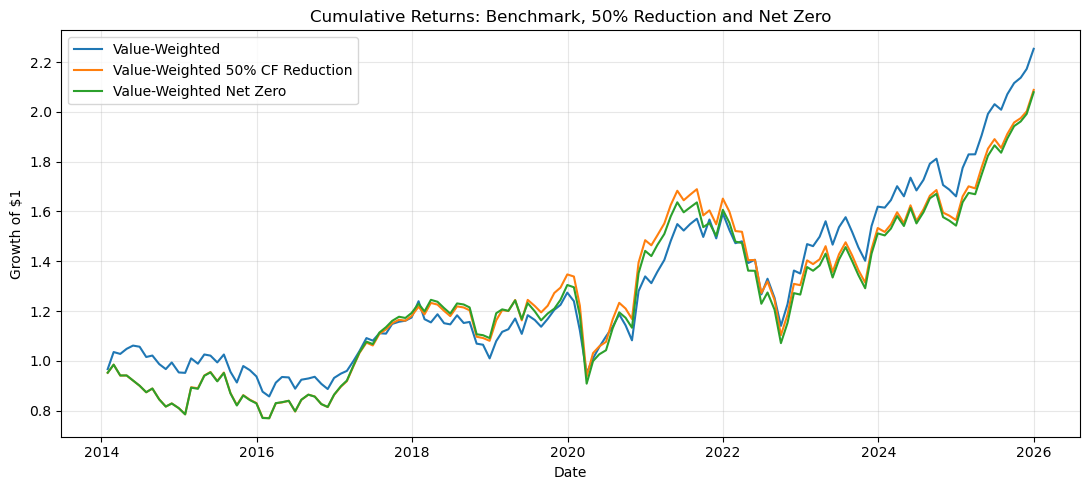

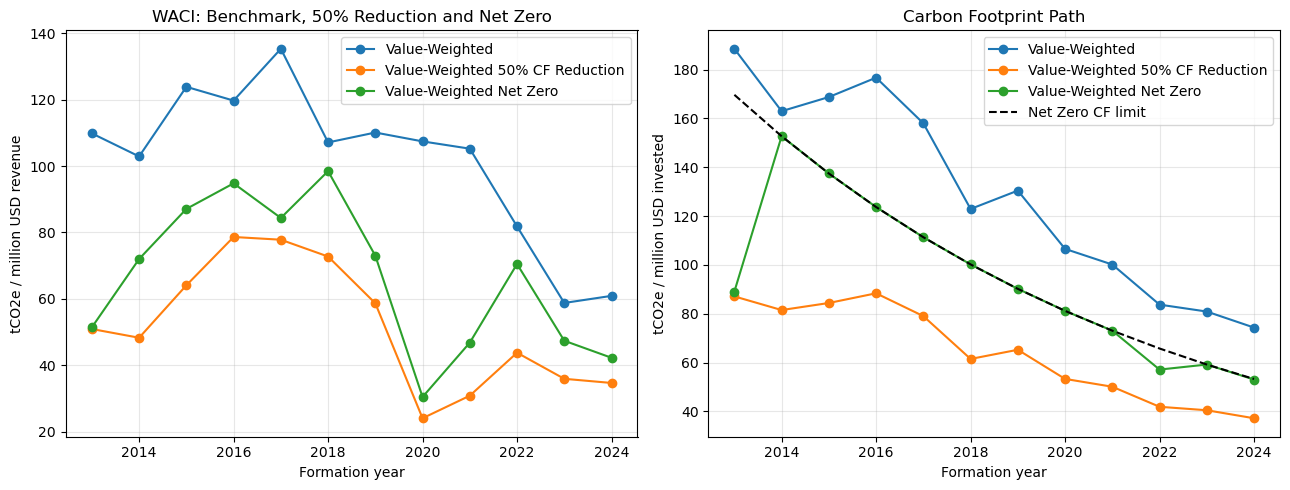

Largest benchmark weight reductions under Net Zero in 2024:
        ISIN               NAME  Value-Weighted  Value-Weighted Net Zero  weight_change
CH0038863350         NESTLE 'N'        0.025347                 0.014912      -0.010435
DE0007236101            SIEMENS        0.012010                 0.002053      -0.009957
IE00BTN1Y115          MEDTRONIC        0.009714                 0.001919      -0.007795
FR0000121972 SCHNEIDER ELECTRIC        0.009735                 0.002099      -0.007635
CH0012032048      ROCHE HOLDING        0.015840                 0.008314      -0.007526
FR0000130403     CHRISTIAN DIOR        0.012184                 0.005164      -0.007020
NO0010096985            EQUINOR        0.007103                 0.000223      -0.006881
GB0002374006             DIAGEO        0.006922                 0.000117      -0.006805
GB00BP6MXD84              SHELL        0.016932                 0.010228      -0.006704
FR0000120321            L'OREAL        0.021557             

In [ ]:
plt.figure(figsize=(11, 5))
for col in netzero_cumulative.columns:
    plt.plot(netzero_cumulative.index, netzero_cumulative[col], label=col)

plt.title("Cumulative Returns: Benchmark, 50% Reduction and Net Zero")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "graph_cumulative_netzero.png", dpi=300, bbox_inches="tight")
plt.show()

netzero_carbon_compare = pd.concat(
    [
        baseline_carbon_metrics[baseline_carbon_metrics["strategy"] == "Value-Weighted"],
        vw50_carbon_metrics,
        netzero_carbon_metrics,
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for strategy, data in netzero_carbon_compare.groupby("strategy"):
    axes[0].plot(data["formation_year"], data["WACI"], marker="o", label=strategy)
    axes[1].plot(data["formation_year"], data["carbon_footprint"], marker="o", label=strategy)

axes[1].plot(
    netzero_constraint_check["formation_year"],
    netzero_constraint_check["net_zero_cf_limit"],
    linestyle="--",
    color="black",
    label="Net Zero CF limit",
)

axes[0].set_title("WACI: Benchmark, 50% Reduction and Net Zero")
axes[0].set_xlabel("Formation year")
axes[0].set_ylabel("tCO2e / million USD revenue")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Carbon Footprint Path")
axes[1].set_xlabel("Formation year")
axes[1].set_ylabel("tCO2e / million USD invested")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "graph_carbon_netzero.png", dpi=300, bbox_inches="tight")
plt.show()

latest_netzero = netzero_weights[latest_year].rename("Value-Weighted Net Zero")
netzero_composition_change = pd.concat([latest_vw, latest_netzero], axis=1).fillna(0)
netzero_composition_change["weight_change"] = (
    netzero_composition_change["Value-Weighted Net Zero"] - netzero_composition_change["Value-Weighted"]
)
netzero_composition_change = netzero_composition_change.reset_index().sort_values("weight_change")

print(f"Largest benchmark weight reductions under Net Zero in {latest_year}:")
print(netzero_composition_change.head(10).to_string(index=False))
print(f"\nLargest benchmark weight increases under Net Zero in {latest_year}:")
print(netzero_composition_change.tail(10).sort_values("weight_change", ascending=False).to_string(index=False))


### Interpretation of the Net Zero portfolio

The Net Zero path becomes stricter over time because the carbon budget is linked to the initial 2013 value-weighted carbon footprint and then decreases by 10% per year. The dashed line in the carbon footprint graph shows this target path.

When the realized portfolio carbon footprint is close to the limit, the constraint is binding and the optimizer has less freedom to stay close to the benchmark. This is why the Net Zero results should be interpreted jointly with ex-post tracking error, active share, and the cumulative return comparison.


### 4.2) Comparison of Portfolios

The Net Zero strategy imposes a progressively tighter carbon footprint path than the fixed 50% reduction rule. The comparison therefore focuses on the possible financial cost of this stronger decarbonization objective.

The final tables consolidate all strategies in a smaller number of CSV files. This avoids exporting a large number of intermediate files while still keeping the information needed for the report: performance statistics, carbon metrics, monthly returns, cumulative returns, constraint checks, and latest-year composition changes.

The consolidated constraint-check file includes the annual carbon limits, realized carbon footprints, active share, and the annual ex-ante tracking error for the tracking-error strategies. The final performance table reports the realized ex-post tracking error over the full out-of-sample period.


In [ ]:
final_carbon_metrics = pd.concat(
    [baseline_carbon_metrics, mv50_carbon_metrics, vw50_carbon_metrics, netzero_carbon_metrics],
    ignore_index=True,
)

final_stats = pd.concat([minvar_50_stats, netzero_stats], axis=0)
final_stats = final_stats[~final_stats.index.duplicated(keep="first")]

# Save only the report-ready tables in this clean notebook version
final_carbon_metrics.to_csv(output_dir / "final_carbon_metrics_all_strategies.csv", index=False)
final_stats.to_csv(output_dir / "final_summary_stats_all_strategies.csv")

monthly_returns_all = pd.concat(
    [
        minvar_50_returns,
        netzero_returns[["Value-Weighted", "Value-Weighted 50% CF Reduction", "Value-Weighted Net Zero"]],
    ],
    axis=1,
).sort_index()
monthly_returns_all.to_csv(output_dir / "monthly_returns_all_strategies.csv")

cumulative_returns_all = (1.0 + monthly_returns_all).cumprod()
cumulative_returns_all.to_csv(output_dir / "cumulative_returns_all_strategies.csv")

mv50_constraints_clean = mv50_constraint_check.rename(
    columns={"baseline_cf": "benchmark_cf", "cf_limit": "carbon_limit"}
).copy()
mv50_constraints_clean.insert(0, "strategy", "Minimum-Variance 50% CF Reduction")

vw50_constraints_clean = vw50_constraint_check.rename(columns={"cf_limit": "carbon_limit"}).copy()
vw50_constraints_clean.insert(0, "strategy", "Value-Weighted 50% CF Reduction")

netzero_constraints_clean = netzero_constraint_check.rename(
    columns={"net_zero_cf_limit": "carbon_limit"}
).copy()
netzero_constraints_clean.insert(0, "strategy", "Value-Weighted Net Zero")

carbon_constraint_checks = pd.concat(
    [mv50_constraints_clean, vw50_constraints_clean, netzero_constraints_clean],
    ignore_index=True,
    sort=False,
)
# This single file replaces the individual annual constraint-check exports
# This table keeps both annual ex-ante TE and full-period ex-post TE for the tracking-error strategies
carbon_constraint_checks.to_csv(output_dir / "carbon_constraint_checks_all_strategies.csv", index=False)

carbon_summary_by_strategy = (
    final_carbon_metrics
    .groupby("strategy")
    .agg(
        avg_WACI=("WACI", "mean"),
        avg_carbon_footprint=("carbon_footprint", "mean"),
        first_carbon_footprint=("carbon_footprint", "first"),
        last_carbon_footprint=("carbon_footprint", "last"),
        first_year=("formation_year", "first"),
        last_year=("formation_year", "last"),
    )
    .reset_index()
)
carbon_summary_by_strategy.to_csv(output_dir / "carbon_summary_by_strategy.csv", index=False)

composition_changes_latest_year = pd.concat(
    [
        mv_composition_change.assign(comparison="Minimum-Variance 50% CF Reduction"),
        vw_composition_change.assign(comparison="Value-Weighted 50% CF Reduction"),
        netzero_composition_change.assign(comparison="Value-Weighted Net Zero"),
    ],
    ignore_index=True,
    sort=False,
)
composition_changes_latest_year.to_csv(output_dir / "composition_changes_latest_year_all_strategies.csv", index=False)

print("Final performance summary:")
print(final_stats.to_string())
print("\nFinal average carbon metrics:")
print(
    final_carbon_metrics
    .groupby("strategy")[["WACI", "carbon_footprint", "attributed_emissions_tonnes"]]
    .mean()
    .sort_values("carbon_footprint")
    .to_string()
)
print("\nAll Part II outputs saved in:", output_dir)


Final performance summary:
                                   Annualized mean return  Annualized volatility  Sharpe ratio  Minimum monthly return  Maximum monthly return  Final cumulative index  Maximum drawdown  Number of monthly observations  Ex-post tracking error vs benchmark
Minimum-Variance                                 0.041307               0.137578      0.173146               -0.120155                0.140773                1.465022         -0.238762                           144.0                             0.000000
Minimum-Variance 50% CF Reduction                0.045657               0.134102      0.210047               -0.115213                0.133309                1.552246         -0.235067                           144.0                             0.016424
Value-Weighted                                   0.080346               0.158463      0.397584               -0.152973                0.182863                2.253411         -0.283950                           

### Final interpretation

The final output compares five strategies: the unconstrained minimum-variance portfolio, the minimum-variance portfolio with a 50% carbon footprint reduction, the value-weighted benchmark, the value-weighted portfolio with a 50% carbon footprint reduction, and the value-weighted Net Zero portfolio.

The main report should use the consolidated final tables rather than the intermediate calculations. The performance table summarizes the financial trade-off, while the carbon tables verify whether the carbon footprint objectives are achieved. The constraint-check table is especially useful because it shows, year by year, that the optimized portfolios respect the required carbon limits up to small numerical tolerances.

The results should be discussed as a portfolio trade-off: carbon footprint can be reduced substantially, but doing so can change diversification, tracking error, and exposure to benchmark sectors or firms.
